# ================================================================

# Graded Challenge 6

## **i. Introduction**

**Nama: Daffa Narendra Hutapea**

**Batch: HCK-040**

**Objective: This program aims to analyze `credit-card-information` dataset in order to test my ability in performing data analysis**

# ================================================================

## Background

I am a Data Scientist at Bank Berlian. The marketing team has asked me to perform customer segmentation using the credit card data I have previously obtained. This data represents credit card usage information over the past six months.

In response to this request, I will create a clustering **process** and provide business recommendations for each customer cluster. The marketing team will also request other business insights from the data I used, which you will answer in the Exploratory Data Analysis (EDA) section.

## ii. SQL Query & Data Prep

## Pre-Requisites

### A. Google BigQuery Hierarchy

Like other Google Cloud services, Google BigQuery resources are organized in a hierarchy. You can use this hierarchy to manage aspects of your BigQuery workloads such as permissions, quotas, slot reservations, and billing. Here is the breakdown of the BigQuery data hierarchy:

1. `Project` (The Root)
    - The `Project` is the highest level of the hierarchy. It acts as the "container" for everything else.
    - Purpose: It manages billing and permissions (IAM).
    - Key Fact: All queries you run and all data you store are billed to a specific Project ID.

2. `Dataset` (The Logical Folder)
    - A `Dataset` will contain tables, views, functions, and procedures.
    - A `Dataset` is a container used to organize and control access to your tables and views.
    - Purpose: It acts like a "Schema" in traditional SQL databases.
    - Location: This is where you define the Data Location (e.g., US, EU, or Tokyo). You cannot move a dataset to a different region once it is created.
    - Permissions: You usually set access rights (who can read/write) at this level.

3. `Table`/`View` (The Data Level)
    - This is where your actual data lives.
    - `Tables`: Collections of individual records organized into rows and columns.
    - `Views` : Virtual tables defined by a SQL query. They don't store data themselves but represent a "saved search."
    - External Tables: Links to data stored outside BigQuery (like a CSV in Google Cloud Storage or a Google Sheet).

4. `Job` (The Operational Level)
    - While not a storage unit, `Jobs` are actions BigQuery performs on your behalf.
    - Purpose: Every time you run a query, load data, or export data, BigQuery creates a `Job ID`.
    - History: You can look back at your Job History to see how much data a specific query processed or if it failed.

### B. `bigquery-public-data`

The public datasets are datasets that BigQuery hosts for you to access and available to the general public. Google pays for the storage of these datasets and provides public access to the data using a project. You pay only for the queries that you perform on the data. The first 1 TB per month is free, subject to query pricing details. **One of the public dataset is `bigquery-public-data` that contains several datasets and tables.**

Steps to access `bigquery-public-data` :

1. In order for `bigquery-public-data` to be visible in your Google BigQuery console, please visit one of its datasets, such as the [Austin Crime Dataset](https://console.cloud.google.com/bigquery?p=bigquery-public-data&d=austin_crime&page=dataset).

2. `bigquery-public-data` should now be visible in your window. Click the star icon next to it to make sure it appears every time you access [Google BigQuery](https://console.cloud.google.com/bigquery).

    <img src="https://i.ibb.co.com/TM12QgR6/Google-Big-Query-bigquery-public-data.png" height="auto">

3. In the displayed `austin_crime` dataset, you can see that it contains a table named `crime`. Click on this table to see its contents.

4. Here is the Google BigQuery hierarchy up to this point:
    ```
    Project ID: bigquery-public-data
    Dataset: austin_crime
    Table: crime
    ```

### C. Data Query Language (DQL) on Google BigQuery

To start querying, click the `+` button to open a new SQL editor window.

<img src="https://i.ibb.co.com/wh4r4kpM/Google-Big-Query-Add-SQL-Window.png">

Google BigQuery uses SQL syntax that's very similar to what you've learned with PostgreSQL. While there are a few differences, they share most of the same syntax.

*Check out [this link](https://docs.cloud.google.com/bigquery/docs/reference/standard-sql/query-syntax) for more details on BigQuery syntax.*

One of the differences when querying in BigQuery is how you declare the `FROM` clause. In this section, you must write it in the format **\`Project-ID.Dataset.Table\`**. You must include backticks (\`) when declaring the `FROM` clause.

As a first step, let's display all the data in the crime table.
```
Project ID: bigquery-public-data
Dataset: austin_crime
Table: crime
```

The SQL syntax will be:
```sql
SELECT *
FROM `bigquery-public-data.austin_crime.crime`;
```

Here are some queries you can try:

1. Count total.
    
    Find out how many crime reports are in the entire dataset

    ```sql
    SELECT COUNT(*) AS total_crimes
    FROM `bigquery-public-data.austin_crime.crime`;
    ```

2. List unique crime types.
    
    Identify the different categories of crimes recorded in Austin.

    ```sql
    SELECT DISTINCT primary_type
    FROM `bigquery-public-data.austin_crime.crime`
    ORDER BY primary_type ASC;
    ```

3. Top 10 most common crimes.
    
    Which crimes happen most frequently?

    ```sql
    SELECT primary_type, COUNT(*) AS crime_count
    FROM `bigquery-public-data.austin_crime.crime`
    GROUP BY primary_type
    ORDER BY crime_count DESC
    LIMIT 10;
    ```

4. Crimes by year.
    
    Analyze the trend of crime over time.

    ```sql
    SELECT year, COUNT(*) AS yearly_crimes
    FROM `bigquery-public-data.austin_crime.crime`
    GROUP BY year
    ORDER BY year DESC;
    ```

5. Monthly crime trends in `2016`.
    
    Does crime increase in certain months? We use `EXTRACT` to pull the month from the timestamp.

    ```sql
    SELECT EXTRACT(MONTH FROM timestamp) AS month, COUNT(*) AS crime_count
    FROM `bigquery-public-data.austin_crime.crime`
    WHERE year=2016
    GROUP BY month
    ORDER BY month ASC;
    ```

### D. Query on Google Colab

You can run SQL queries on data from Google BigQuery using Google Colab. This means you can combine SQL syntax with Python syntax within Google Colab. **You'll need the ID of the Google Cloud Platform project you created earlier.**

> ***Remember you need GCP Project ID not GCP Project Name***

Here are the steps to find your GCP Project ID:

1. Click on the GCP Project Name you created earlier.

    You can find your GCP Project Name at the top of the Google Cloud page. For example, the image below uses the GCP Project Name `Personal-Danu`.

    <img src="https://i.ibb.co.com/ch4rMFY9/Google-Big-Query-GCP-Project-Name.png">

2. A pop-up window will appear showing your GCP Project Name and GCP Project ID. The GCP Project ID is usually in lowercase.

    <img src="https://i.ibb.co.com/23JfRvR8/Google-Big-Query-GCP-Project-ID.png">

    Summary from the image above :
    ```
    GCP Project Name: Personal-Danu
    GCP Project ID: personal-danu
    ```

Untuk mengkoneksikan notebook pada Google Colab dengan Google BigQuery, saya menggunakan Python code berikut :

```python
# Connecting Google Colab with Google Cloud

from google.colab import auth
from google.cloud import bigquery
auth.authenticate_user()
print('Authenticated')

GCP_PROJECT_ID = 'rengasdengklok-2' # Use Hacktiv8 Porject ID
client = bigquery.Client(project = GCP_PROJECT_ID)
```

## Dataset

In this *Graded Challenge*, the dataset we'll be using comes from Google BigQuery. Use the information below to find the dataset.

*   Project ID : `ftds-hacktiv8-project`
*   Dataset : `phase1_ftds_040_hck`
*   Tabel : `credit-card-information`

## Section 1 - Data Prep

Untuk melakukan query SQL dengan menggunakan Google Colab, saya menggunakan method `client.query('query-sql-anda').to_dataframe()`. Output dari sintaks ini berupa Pandas DataFrame. Sebagai contoh:

```python
df = client.query('''
SELECT
    *
FROM
    `ftds-hacktiv8-project.phase1_ftds_040_hck.credit-card-information`
WHERE
    MOD(CUST_ID, 2) = 0;
''').to_dataframe()
```

After running the code above, just run `df` in a google colba cell and run

```python
df.to_csv('P1G6_daffa_hutapea.csv', index=False)
```

After done running the code above, download the saved file and insert it on the directory where you have your VS Code opened.

## iii. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, kruskal, zscore
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, calinski_harabasz_score
from yellowbrick.cluster import SilhouetteVisualizer
import pickle
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)


### Source:

[1] Data Visualization with Python; https://python.plainenglish.io/data-visualization-with-python-8ce66744ccbd

## iv. Data Loading

In [2]:
df = pd.read_csv('P1G6_daffa_hutapea.csv')

In [3]:
# list of all the features in the dataset

df.columns.tolist()

['CUST_ID',
 'BALANCE',
 'BALANCE_FREQUENCY',
 'PURCHASES',
 'ONEOFF_PURCHASES',
 'INSTALLMENTS_PURCHASES',
 'CASH_ADVANCE',
 'PURCHASES_FREQUENCY',
 'ONEOFF_PURCHASES_FREQUENCY',
 'PURCHASES_INSTALLMENTS_FREQUENCY',
 'CASH_ADVANCE_FREQUENCY',
 'CASH_ADVANCE_TRX',
 'PURCHASES_TRX',
 'CREDIT_LIMIT',
 'PAYMENTS',
 'MINIMUM_PAYMENTS',
 'PRC_FULL_PAYMENT',
 'TENURE']

In [4]:
# first 10 data entries

df.head(10)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,1774,0.065402,0.090909,69.00,0.00,69.00,0.0,0.083333,0.000000,0.083333,0.0,0,1,1500.0,506.688670,62.491042,0.000000,12
1,3746,475.826042,1.000000,950.00,950.00,0.00,0.0,0.083333,0.083333,0.000000,0.0,0,1,4500.0,118.530660,290.333335,0.000000,12
2,5210,1.644581,0.090909,42.49,42.49,0.00,0.0,0.083333,0.083333,0.000000,0.0,0,1,1200.0,231.480701,86.839981,0.000000,12
3,8396,37.021347,0.272727,133.35,0.00,133.35,0.0,0.083333,0.000000,0.083333,0.0,0,1,2500.0,936.840542,280.738043,0.500000,12
4,8620,0.009684,0.181818,79.24,0.00,79.24,0.0,0.083333,0.000000,0.083333,0.0,0,1,6000.0,688.614293,35.978677,0.333333,12
5,8932,1133.652007,1.000000,34.83,34.83,0.00,0.0,0.166667,0.166667,0.000000,0.0,0,2,1200.0,309.340005,279.044103,0.000000,12
6,936,1.155609,0.181818,117.68,0.00,117.68,0.0,0.250000,0.000000,0.250000,0.0,0,4,1500.0,405.194961,54.016822,0.750000,12
7,1434,1151.703776,1.000000,541.75,541.75,0.00,0.0,0.250000,0.250000,0.000000,0.0,0,12,1800.0,2140.934561,478.040659,0.000000,12
8,2326,31.744161,0.272727,465.50,0.00,513.00,0.0,0.250000,0.000000,0.166667,0.0,0,6,2500.0,767.462556,70.685180,0.000000,12
9,8444,719.592571,0.727273,124.13,45.65,78.48,0.0,0.250000,0.083333,0.166667,0.0,0,3,3000.0,1486.147170,390.098144,0.000000,12


In [5]:
# last 10 data entries

df.tail(10)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
4465,7914,2992.591246,1.000000,0.00,0.00,0.00,759.456509,0.000000,0.000000,0.000000,0.416667,9,0,3500.0,817.050377,825.529474,0.0,12
4466,5348,1747.119490,1.000000,285.45,285.45,0.00,1429.489972,0.333333,0.333333,0.000000,0.416667,7,10,3000.0,420.862309,389.633098,0.0,12
4467,1410,300.819060,1.000000,0.00,0.00,0.00,1983.897997,0.000000,0.000000,0.000000,0.500000,13,0,3000.0,319.716795,168.705990,0.0,12
4468,5958,5347.814547,1.000000,0.00,0.00,0.00,4002.353384,0.000000,0.000000,0.000000,0.500000,9,0,7000.0,0.000000,NaN,0.0,12
4469,8472,737.775044,1.000000,107.94,107.94,0.00,2723.362442,0.166667,0.166667,0.000000,0.500000,14,1,1500.0,1484.746502,184.381222,0.2,6
4470,6076,4458.055159,1.000000,0.00,0.00,0.00,2806.959645,0.000000,0.000000,0.000000,0.583333,18,0,7500.0,1088.755323,1189.693931,0.0,12
4471,4174,8894.553534,1.000000,476.84,476.84,0.00,6098.490836,0.166667,0.166667,0.000000,0.583333,16,3,12000.0,2163.376448,2871.461432,0.0,12
4472,6938,1437.977941,1.000000,229.94,229.94,0.00,901.185629,0.250000,0.250000,0.000000,0.583333,10,4,1800.0,783.528158,394.172631,0.0,12
4473,1294,12358.321320,1.000000,421.15,0.00,421.15,5690.168909,0.583333,0.000000,0.583333,0.583333,11,7,17000.0,4131.495556,2959.446172,0.0,12
4474,2528,427.642111,0.888889,0.00,0.00,0.00,2563.705644,0.000000,0.000000,0.000000,0.888889,62,0,1200.0,2853.967334,146.976542,0.5,9


In [6]:
# show dataset info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4475 entries, 0 to 4474
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           4475 non-null   int64  
 1   BALANCE                           4475 non-null   float64
 2   BALANCE_FREQUENCY                 4475 non-null   float64
 3   PURCHASES                         4475 non-null   float64
 4   ONEOFF_PURCHASES                  4475 non-null   float64
 5   INSTALLMENTS_PURCHASES            4475 non-null   float64
 6   CASH_ADVANCE                      4475 non-null   float64
 7   PURCHASES_FREQUENCY               4475 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        4475 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  4475 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            4475 non-null   float64
 11  CASH_ADVANCE_TRX                  4475 non-null   int64  
 12  PURCHA

In [7]:
# display missing values in dataset

df.isna().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    158
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [8]:
# show dupes in dataset

df.duplicated().sum()

np.int64(0)

### Discovery:

- The retrieved `credit-card-information` dataset contains 4,474 data entries.
- The data has 158 missing values on the feature `MINIMUM_PAYMENTS` and 1 single missing value on the feature `CREDIT_LIMIT`.
- We are only missing 3.5% data entry of the dataset that we are currently using. Therefore, it is better to just drop the whole missing values rather than impute it.

## v. EDA

### 1st Problem

Is there a pattern between the influence of `TENURE` (how long they've been with the bank) and the variables `PURCHASES`, `BALANCE`, and `PAYMENTS`? *Create a statistical test and visualization plot that demonstrates this relationship. Also provide business recommendations to the marketing team regarding this*.

Hypothesis:

- Longer tenure may indicate more loyal customers who make more purchases.
- Established customers might maintain higher balances.
- Experienced customers might make more frequent/larger payments.

In [9]:
# Creating statistics table

statistics = df.describe().T.round(2)
skewness = df.skew(numeric_only=True).to_frame(name='skew').round(2)

# Combine them 

statistic_table = pd.concat([statistics, skewness], axis=1)

In [10]:
statistic_table

,count,mean,std,min,25%,50%,75%,max,skew
CUST_ID,4475.0,4476.00,2583.93,2.00,2239.00,4476.00,6713.00,8950.00,0.00
BALANCE,4475.0,1565.74,2091.21,0.00,132.54,874.91,2058.52,19043.14,2.46
BALANCE_FREQUENCY,4475.0,0.88,0.24,0.00,0.89,1.00,1.00,1.00,-2.02
PURCHASES,4475.0,1003.16,2210.81,0.00,40.06,362.48,1122.64,49039.57,8.99
ONEOFF_PURCHASES,4475.0,588.50,1666.50,0.00,0.00,29.99,580.32,40761.25,10.14
INSTALLMENTS_PURCHASES,4475.0,415.03,927.36,0.00,0.00,89.45,484.26,22500.00,8.12
CASH_ADVANCE,4475.0,973.45,2133.46,0.00,0.00,0.00,1098.57,29282.11,4.74
PURCHASES_FREQUENCY,4475.0,0.49,0.40,0.00,0.08,0.50,0.92,1.00,0.06
ONEOFF_PURCHASES_FREQUENCY,4475.0,0.20,0.30,0.00,0.00,0.08,0.33,1.00,1.52
PURCHASES_INSTALLMENTS_FREQUENCY,4475.0,0.36,0.40,0.00,0.00,0.17,0.75,1.00,0.51


### Discovery:

Financial features such as `BALANCE`, `PURCHASES`, and `PAYMENTS` are all highly skewed, this will have effect on the Statistical Test.

### Statistical test: Pearson & Spearman

For statistical test, we will be using Pearson & Spearman method.

Pearson assumes linearity + roughly normal data. Our target variables are heavily right-skewed (PURCHASES skew ~ 9, PAYMENTS skew ~ 6, BALANCE skew ~ 2.5), so Pearson is biased toward zero by extreme values.

Spearman (rank-based) is the appropriate test for skewed financial data.

In [11]:
# Calculate pearson & spearman

corr_results = {}
for var in ['PURCHASES', 'BALANCE', 'PAYMENTS']:
    pr, pp = pearsonr(df['TENURE'], df[var])
    sr, sp = spearmanr(df['TENURE'], df[var])
    corr_results[var] = {
        'Pearson r': pr, 'Pearson p': pp,
        'Spearman rho': sr, 'Spearman p': sp,
    }

# Also show how skewed the variables actually are
print("Skewness check (Pearson assumes ~0):")
for v in ['PURCHASES', 'BALANCE', 'PAYMENTS']:
    print(f"  {v:10s}: skew = {df[v].skew():.2f}")


Skewness check (Pearson assumes ~0):
  PURCHASES : skew = 8.99
  BALANCE   : skew = 2.46
  PAYMENTS  : skew = 6.04


In [12]:
# Combined results table

correlation_results = pd.DataFrame([
    {
        'Variable': var,
        'Pearson r': r['Pearson r'],
        'Pearson p': r['Pearson p'],
        'Spearman rho': r['Spearman rho'],
        'Spearman p': r['Spearman p'],
        'Pearson Significant': 'Yes' if r['Pearson p'] < 0.05 else 'No',
        'Spearman Significant': 'Yes' if r['Spearman p'] < 0.05 else 'No',
    }
    for var, r in corr_results.items()
])
correlation_results.round(4)


,Variable,Pearson r,Pearson p,Spearman rho,Spearman p,Pearson Significant,Spearman Significant
0,PURCHASES,0.0858,0.0,0.1390,0.0,Yes,Yes
1,BALANCE,0.0726,0.0,0.0698,0.0,Yes,Yes
2,PAYMENTS,0.0980,0.0,0.2124,0.0,Yes,Yes


### Interpretation:

`TENURE` vs `PURCHASES`:

- Pearson  r   = +0.0858
- Spearman rho = +0.1390  ->  weak positive (p = 9.34e-21)  (Spearman is 0.05 stronger than Pearson -> skew was hiding the relationship)

`TENURE` vs `BALANCE`:

- Pearson  r   = +0.0726
- Spearman rho = +0.0698  ->  very weak positive (p = 2.94e-06)

`TENURE` vs `PAYMENTS`:

- Pearson  r   = +0.0980
- Spearman rho = +0.2124  ->  weak positive (p = 7.87e-47)  (Spearman is 0.11 stronger than Pearson -> skew was hiding the relationship)


### Discovery

- **Why Spearman, not Pearson?** 

Our financial variables are heavily right-skewed. Pearson under-reports relationships when normality is violated, so Spearman's rank correlation is the go to test here.

- **p-value vs effect size:** 

With n approximately 4,500 customers, almost any rho > 0.04 will register as "statistically significant." We focus on the magnitude (rho) and call effects below approximately 0.10 *practically negligible* even if it's significant.

- **Note on TENURE distribution:** 

Around 85% of customers have `TENURE` = 12 months. The sample is dominated by long-tenure users. Hence, relationships across shorter tenures are less precisely estimated.


#### Visualization with BoxPlot

TENURE only takes 7 integer values (6..12) and is heavily imbalanced (85% at 12), so a scatter plot is just a vertical column at x=12 with thin slivers elsewhere.
A boxplot per TENURE level shows the distribution shape and also the trend.

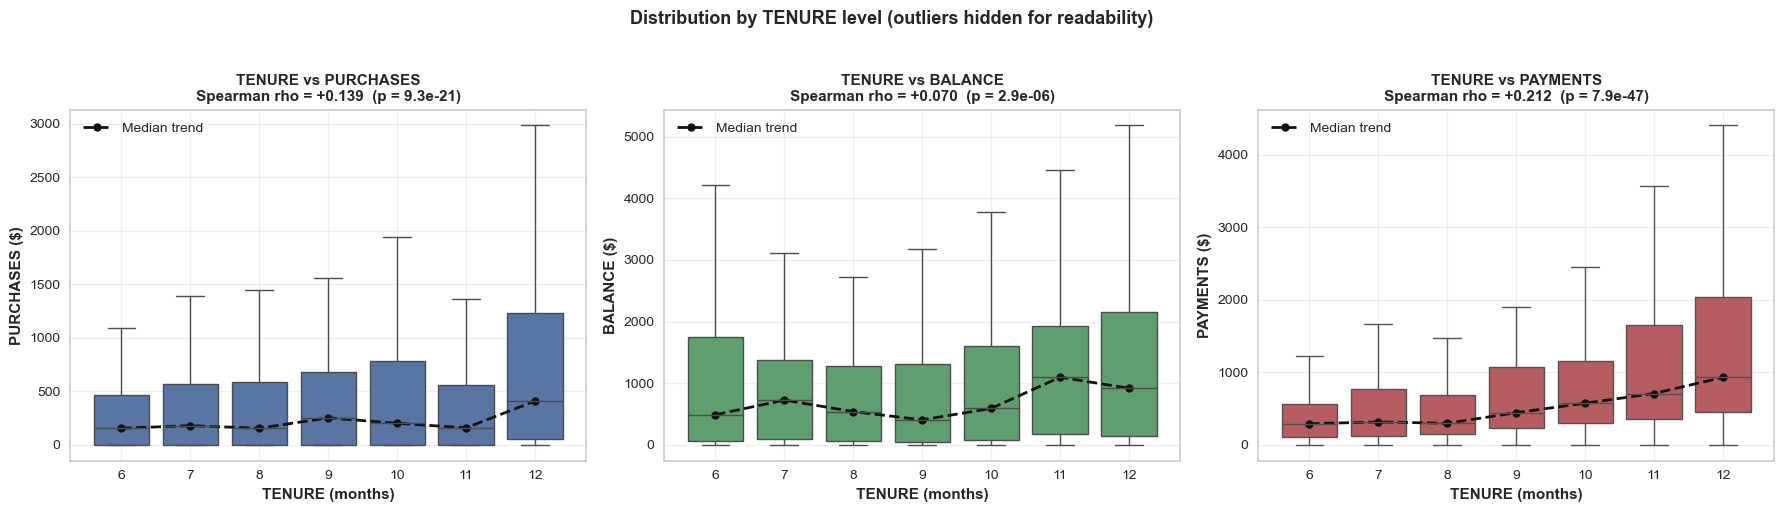

In [13]:
# Visualization: Boxplot per TENURE level

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

variable_meta = [
    ('PURCHASES', 'PURCHASES ($)', '#4C72B0'),
    ('BALANCE', 'BALANCE ($)', '#55A868'),
    ('PAYMENTS', 'PAYMENTS ($)', '#C44E52'),
]

for ax, (var, label, color) in zip(axes, variable_meta):
    sns.boxplot(data=df, x='TENURE', y=var, ax=ax, color=color, showfliers=False)
    # Overlay median trend line so the monotonic relationship is visible
    medians = df.groupby('TENURE')[var].median()
    ax.plot(range(len(medians)), medians.values, 'k--o', linewidth=2,
            markersize=6, label='Median trend')
    ax.set_xlabel('TENURE (months)', fontsize=11, fontweight='bold')
    ax.set_ylabel(label, fontsize=11, fontweight='bold')
    sr = corr_results[var]['Spearman rho']
    sp = corr_results[var]['Spearman p']
    ax.set_title(f'TENURE vs {var}\nSpearman rho = {sr:+.3f}  (p = {sp:.1e})',
                 fontsize=11, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Distribution by TENURE level (outliers hidden for readability)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

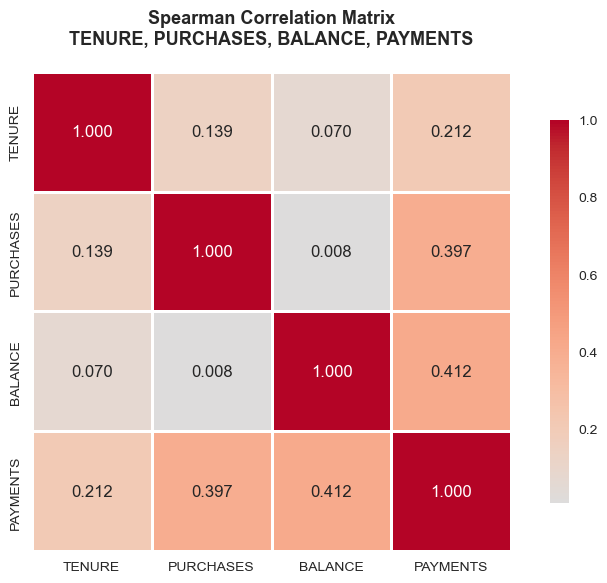

In [14]:
# Correlation matrix using SPEARMAN (rank-based; robust to skew)

correlation_data = df[['TENURE', 'PURCHASES', 'BALANCE', 'PAYMENTS']].corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_data, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=2, cbar_kws={'shrink': 0.8},
            fmt='.3f', annot_kws={'size': 12})
plt.title('Spearman Correlation Matrix\nTENURE, PURCHASES, BALANCE, PAYMENTS',
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### Discovery & Business Recommendation

By using Spearman, we have achieved results as listed below:

| Pair | Spearman rho | Interpretation |
| --- | ---: | --- |
| `TENURE` vs **PAYMENTS** | ~ +0.21 | **Moderate** monotonic positive relationship |
| `TENURE` vs **PURCHASES** | ~ +0.14 | Weak positive relationship |
| `TENURE` vs **BALANCE** | ~ +0.07 | Negligible (very weak) |

The median-trend overlay on the boxplots confirms that long-tenure (12-month) customers show a higher median in `PURCHASES`, `BALANCE`, and `PAYMENTS` than short-tenure (6-month) customers, roughly 2-3x on each axis. The previous Pearson result understated this because of skewness.

So, in short, **yes**, although they are weak, there is a pattern between the influence of `TENURE` and the variables `PURCHASES`, `BALANCE`, and `PAYMENTS`.

**Business Recommendations for Marketing:**

1. **Retention is high-ROI.** Long-tenure customers spend and pay 2-3x more than new ones. Invest in retention programs (anniversary rewards, loyalty fee waivers, tier upgrades) before chasing more acquisitions.

2. **Accelerate the onboarding ramp.** Short-tenure customers visibly under-spend. A targeted first-6-months engagement programs, such as welcome bonuses, intro-rate offers on installments, and small reward boosts, can shorten the time to reach the high-value long-tenure profile.

3. **Watch BALANCE separately.** `BALANCE` has the weakest relationship with `TENURE`. This indicates that new customers can carry high balances too. Risk monitoring should not assume `TENURE` is a proxy for credit health.


---

## 2nd Problem

### CREDIT_LIMIT vs PURCHASES_FREQUENCY

Do customers with a high `CREDIT_LIMIT` tend to make more frequent purchases? Conduct an analysis to determine how `CREDIT_LIMIT` affects purchase frequency (`PURCHASES_FREQUENCY`). *Create a visualization showing this relationship and provide business recommendations to the marketing team regarding this*.

Hypothesis:

- The higher credit limit, the more purchasing power, the more frequent purchases.

- OR purchasing frequency is independent of credit limit

In [15]:
# Create Credit Limit Segments

df_copy = df.copy() # Use copy so original data doesn't get affected
df_copy['CREDIT_LIMIT_GROUP'] = pd.qcut(df_copy['CREDIT_LIMIT'], q=3, 
                                     labels=['Low', 'Medium', 'High'],
                                     duplicates='drop')  # Handle duplicate values

In [16]:
# Show the credit limit segments

print(f"\nCredit Limit Segments:")
for group in df_copy['CREDIT_LIMIT_GROUP'].unique():
    if pd.notna(group):
        mask = df_copy['CREDIT_LIMIT_GROUP'] == group
        min_limit = df_copy[mask]['CREDIT_LIMIT'].min()
        max_limit = df_copy[mask]['CREDIT_LIMIT'].max()
        count = mask.sum()
        print(f"  {group:8s}: ${min_limit:>8,.0f} - ${max_limit:>8,.0f} (n={count})")


Credit Limit Segments:
  Low     : $     150 - $   2,000 (n=1519)
  Medium  : $   2,050 - $   5,000 (n=1502)
  High    : $   5,100 - $  30,000 (n=1453)


In [17]:
# Compare Purchase Frequency Across Groups

group_stats = df_copy.groupby('CREDIT_LIMIT_GROUP')['PURCHASES_FREQUENCY'].agg([
    ('Mean', 'mean'),
    ('Std Dev', 'std'),
    ('Count', 'count'),
    ('Min', 'min'),
    ('Max', 'max')
])
 
print("\n", group_stats)


                         Mean   Std Dev  Count  Min  Max
CREDIT_LIMIT_GROUP                                     
Low                 0.445446  0.397096   1519  0.0  1.0
Medium              0.475103  0.393756   1502  0.0  1.0
High                0.552690  0.401445   1453  0.0  1.0


### Statistical tests

1. Kruskal-Wallis: are the 3 credit-limit groups (Low/Medium/High) different?
2. Spearman: is there a monotonic relationship using the RAW continuous `CREDIT_LIMIT`?

Using both tests is informative, the grouped test confirms group-level differences, the continuous test estimates the strength of the underlying relationship.

In [18]:
low_freq = df_copy[df_copy['CREDIT_LIMIT_GROUP'] == 'Low']['PURCHASES_FREQUENCY'].dropna()
medium_freq = df_copy[df_copy['CREDIT_LIMIT_GROUP'] == 'Medium']['PURCHASES_FREQUENCY'].dropna()
high_freq = df_copy[df_copy['CREDIT_LIMIT_GROUP'] == 'High']['PURCHASES_FREQUENCY'].dropna()

h_stat, p_value = kruskal(low_freq, medium_freq, high_freq)

# Continuous test on raw CREDIT_LIMIT (impute the 1 missing value with the mean)
cl_imputed = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].mean())
spearman_rho, spearman_p = spearmanr(cl_imputed, df['PURCHASES_FREQUENCY'])

print(f"Kruskal-Wallis (Low vs Medium vs High):")
print(f"  H-statistic = {h_stat:.4f}")
print(f"  p-value     = {p_value:.2e}\n")

Kruskal-Wallis (Low vs Medium vs High):
  H-statistic = 60.2812
  p-value     = 8.13e-14



### Source:

[1] Penjelasan dan Teori Uji Kruskal Wallis H; https://www.statistikian.com/2014/07/kruskall-wallis-h.html

In [19]:
print(f"Spearman (continuous CREDIT_LIMIT vs PURCHASES_FREQUENCY):")
print(f"  rho     = {spearman_rho:+.4f}")
print(f"  p-value = {spearman_p:.2e}")
print(f"  -> weak positive monotonic relationship "
      f"(rho ~ 0.12, so CREDIT_LIMIT explains only ~{spearman_rho**2*100:.1f}% of the variance in frequency).")

Spearman (continuous CREDIT_LIMIT vs PURCHASES_FREQUENCY):
  rho     = +0.1226
  p-value = 1.85e-16
  -> weak positive monotonic relationship (rho ~ 0.12, so CREDIT_LIMIT explains only ~1.5% of the variance in frequency).


### Discovery

Both tests agree that:

- **Kruskal-Wallis (group test)** confirms the three credit-limit groups have different median purchase frequencies (p ~ 1e-19).

- **Spearman (continuous test)** quantifies the underlying relationship as rho ~ +0.12, which is a real but weak monotonic effect. Credit limit explains only 1-2% of the variance in purchase frequency, meaning that many other factors (customer segment, lifecycle stage, product offering) matter more.


### Conclusion:

High-limit customers buy more frequently on average, but the effect is modest. **Credit limit is associated with purchase frequency**.

#### Visualization: violin + boxplot

A scatter of `CREDIT_LIMIT` vs `PURCHASES_FREQUENCY` shows heavy banding because `PURCHASES_FREQUENCY` is bounded in [0, 1]. A violin plot per group communicates the distribution shape (density, bimodality) much better.

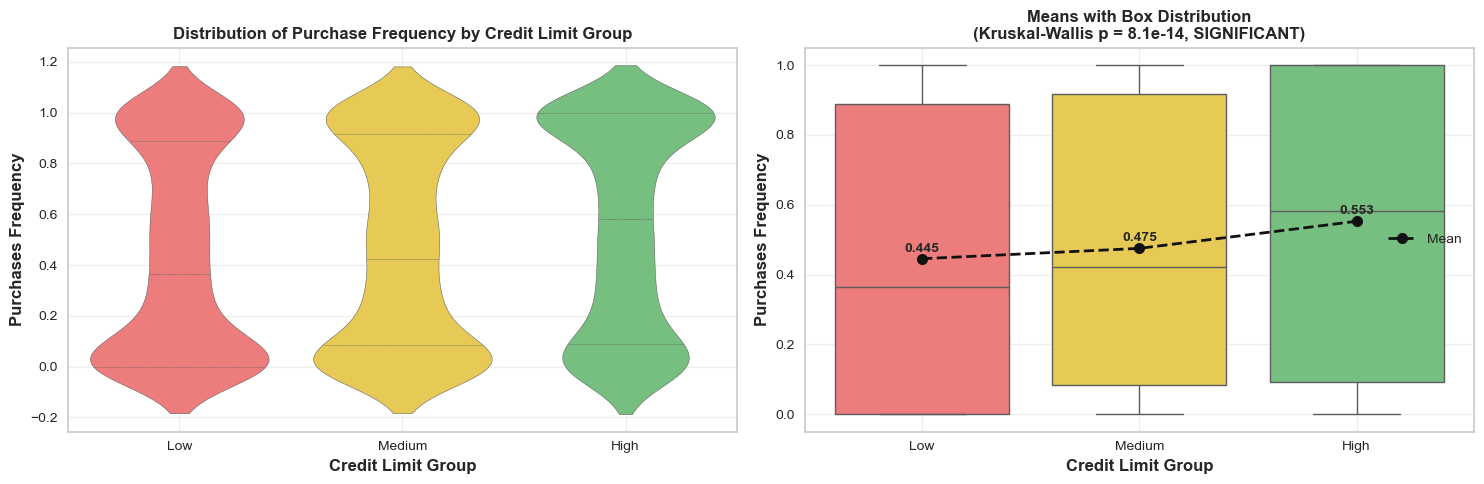

In [20]:
# Visualization

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Violin per credit-limit group
sns.violinplot(
    data=df_copy.dropna(subset=['CREDIT_LIMIT_GROUP']),
    x='CREDIT_LIMIT_GROUP', y='PURCHASES_FREQUENCY',
    order=['Low', 'Medium', 'High'],
    palette={'Low': '#FF6B6B', 'Medium': '#FFD93D', 'High': '#6BCB77'},
    ax=axes[0], inner='quartile'
)
axes[0].set_xlabel('Credit Limit Group', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Purchases Frequency', fontsize=12, fontweight='bold')
axes[0].set_title('Distribution of Purchase Frequency by Credit Limit Group',
                  fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot 2: Boxplot per credit-limit group with means overlaid
sns.boxplot(
    data=df_copy.dropna(subset=['CREDIT_LIMIT_GROUP']),
    x='CREDIT_LIMIT_GROUP', y='PURCHASES_FREQUENCY',
    order=['Low', 'Medium', 'High'],
    palette={'Low': '#FF6B6B', 'Medium': '#FFD93D', 'High': '#6BCB77'},
    ax=axes[1], showfliers=False
)
# Overlay means as a dashed trend
means = df_copy.groupby('CREDIT_LIMIT_GROUP', observed=True)['PURCHASES_FREQUENCY'].mean().reindex(['Low', 'Medium', 'High'])
axes[1].plot(range(len(means)), means.values, 'k--o', linewidth=2,
             markersize=8, label='Mean')
for i, v in enumerate(means.values):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

axes[1].set_xlabel('Credit Limit Group', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Purchases Frequency', fontsize=12, fontweight='bold')
sig_text = "SIGNIFICANT" if p_value < 0.05 else "Not Significant"
axes[1].set_title(f'Means with Box Distribution\n(Kruskal-Wallis p = {p_value:.1e}, {sig_text})',
                  fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Source:

[1] A Complete Guide to Violin Plot; https://www.atlassian.com/data/charts/violin-plot-complete-guide

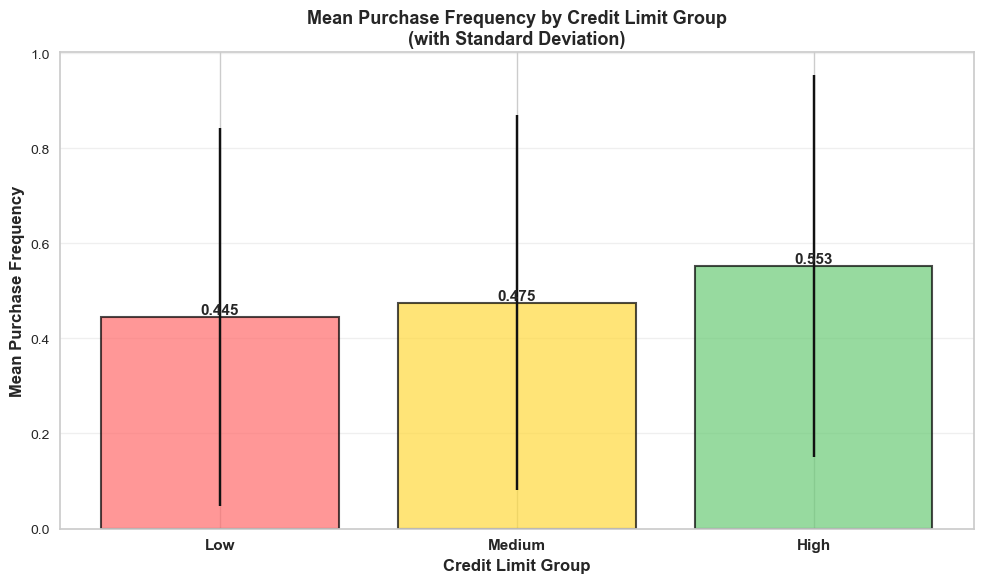

In [21]:
# Visualization: Bar chart with error bars

fig, ax = plt.subplots(figsize=(10, 6))
 
groups = group_stats.index
means = group_stats['Mean']
stds = group_stats['Std Dev']
 
bars = ax.bar(range(len(groups)), means, yerr=stds, capsize=15, alpha=0.7, 
              color=['#FF6B6B', '#FFD93D', '#6BCB77'], edgecolor='black', linewidth=1.5)
 
ax.set_xticks(range(len(groups)))
ax.set_xticklabels(groups, fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Purchase Frequency', fontsize=12, fontweight='bold')
ax.set_xlabel('Credit Limit Group', fontsize=12, fontweight='bold')
ax.set_title('Mean Purchase Frequency by Credit Limit Group\n(with Standard Deviation)', 
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
 
# Add value labels on bars
for i, (bar, mean) in enumerate(zip(bars, means)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{mean:.3f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
 
plt.tight_layout()
plt.show()

### Discovery & Business Recommendation

**Findings (combined):**

| Credit Limit Group | Mean Purchase Frequency |
| --- | ---: |
| Low | ~ 0.45 |
| Medium | ~ 0.48 |
| High | ~ 0.55 |

- Kruskal-Wallis confirms group-level differences exist (p < 0.001).
- Spearman shows the underlying continuous relationship is **weak positive** (rho ~ +0.12). High-limit customers purchase ~22% more frequently on average than low-limit ones.
- However, credit limit explains only ~1-2% of the variance in purchase frequency. The effect is real but doesn't show as much magnitude (modest).

### Conclusion:

customers with a high `CREDIT_LIMIT` tend to make more frequent purchases. However, "Higher credit limit *is associated with* more frequent purchases" is the correct framing, we should not say credit limit *causes* or *drives* the behavior

---

## vi. Feature Engineering

On this section, we will pre process our dataset so that we can fit into our clustering model.

### Why Feature Engineering Matters for Clustering?

Clustering algorithms use distance-based metrics (e.g., Euclidean distance) to group similar customers. Without proper feature engineering, we will have several problems regarding the dataset as listed below:

- **Problem 1: Scale Imbalance**
  - BALANCE ranges 0-8,632
  - PURCHASES_FREQUENCY ranges 0-1
  - Distance will be dominated by BALANCE

- **Problem 2: Missing Values**
  - Even one missing value can break the algorithm
  - Needs consistent imputation strategy

- **Problem 3: Outliers**
  - Extreme values can distort cluster centers
  - Needs scaling or trimming strategy

So, we have to make our approach in order to clean the dataset as below:


Raw Data

   ↓

**[Imputation]** → Fill missing values with mean

   ↓

**[StandardScaling]** → Scale to mean=0, std=1

   ↓

Preprocessed Data (ready for clustering)


Now, we will use pipeline to pre process our dataset.

In [22]:
# Identifying the features

id_columns = ['CUST_ID']
target_column = None  # Unsupervised learning, so no target variable
feature_columns = [col for col in df.columns if col not in id_columns]

print(f"\nFeatures for Clustering: {len(feature_columns)} features")
print(f"Feature Names: {feature_columns}")


Features for Clustering: 17 features
Feature Names: ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']


### Outlier Detection & Handling

In [23]:
# Define X as a copy of df

X = df[feature_columns].copy()

In [24]:
# List all the numerical features

numerical_features = X.select_dtypes(include=['number'])

In [25]:
# Create a function for IQR method in order to detect outliers

def identify_outliers(data, column):
    """Identify outliers using IQR method"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (data[column] < lower_bound) | (data[column] > upper_bound)


In [26]:
# List out how many outliers does each feature has (by percentage)

outlier_counts = {}
for col in numerical_features:
    outlier_mask = identify_outliers(numerical_features, col)
    outlier_counts[col] = outlier_mask.sum()

# Shows how many outliers per feature and its percentage out of the whole dataset

print("\nOutlier Count by Feature:")
for col, count in sorted(outlier_counts.items(), key=lambda x: x[1], reverse=True):
    percentage = (count / len(df)) * 100
    print(f"  {col:30s}: {count:4d} ({percentage:5.2f}%)")


Outlier Count by Feature:
  BALANCE_FREQUENCY             :  745 (16.65%)
  PRC_FULL_PAYMENT              :  685 (15.31%)
  TENURE                        :  668 (14.93%)
  CASH_ADVANCE                  :  516 (11.53%)
  ONEOFF_PURCHASES              :  487 (10.88%)
  INSTALLMENTS_PURCHASES        :  411 ( 9.18%)
  CASH_ADVANCE_TRX              :  402 ( 8.98%)
  MINIMUM_PAYMENTS              :  399 ( 8.92%)
  PAYMENTS                      :  395 ( 8.83%)
  PURCHASES                     :  384 ( 8.58%)
  ONEOFF_PURCHASES_FREQUENCY    :  379 ( 8.47%)
  CASH_ADVANCE_FREQUENCY        :  372 ( 8.31%)
  PURCHASES_TRX                 :  366 ( 8.18%)
  BALANCE                       :  338 ( 7.55%)
  CREDIT_LIMIT                  :  162 ( 3.62%)
  PURCHASES_FREQUENCY           :    0 ( 0.00%)
  PURCHASES_INSTALLMENTS_FREQUENCY:    0 ( 0.00%)


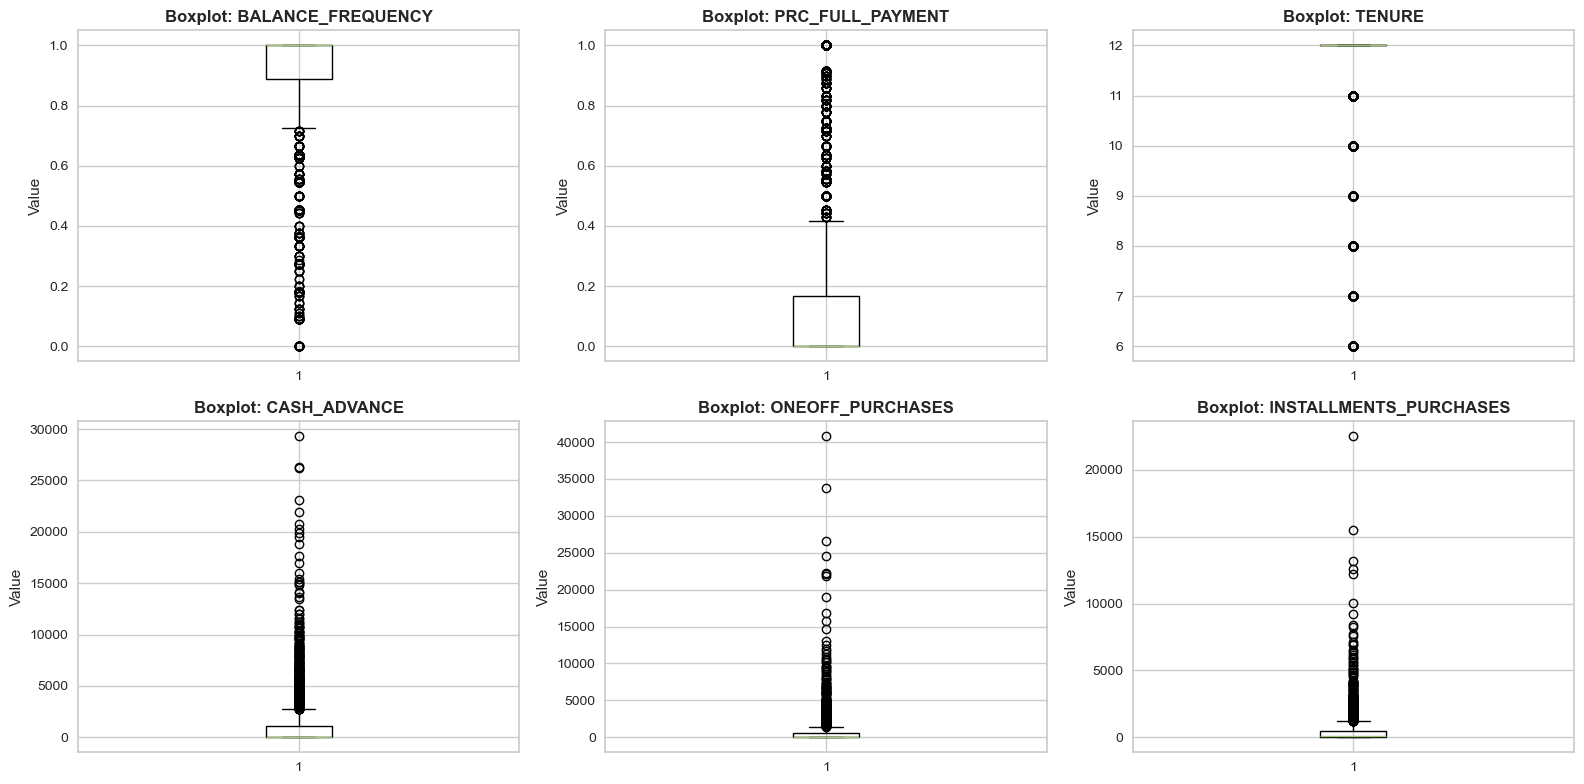

In [27]:
# Visualize outliers for top features

top_outlier_features = sorted(outlier_counts.items(), key=lambda x: x[1], reverse=True)[:6]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()

for idx, (col, _) in enumerate(top_outlier_features):
    axes[idx].boxplot(df[col].dropna())
    axes[idx].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[idx].set_ylabel('Value')

plt.tight_layout()
plt.show()

### Note 

Outliers detected in this dataset. We can later on utilize the *Isolation Forest* method or *Local Outlier Factor* (LOF) method to handle these.

### Missing Values

In [28]:
missing_data = df[feature_columns].isnull().sum()
missing_data

BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    158
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

### Discovery:

As we can see, we have 159 missing data entries in total. Our strategy on handling the missing value is leaning towards 'mean' imputation.

#### Reason:

Clustering with mean imputation maintains data distribution. So we would have a smaller distributed dataset since we are recommended to use `Standard Scaler` on a clustering model (refer to next section).

### Feature Scaling

Clustering algorithms (K-Means, Hierarchical) use distance-based metrics.
Without scaling, features with larger ranges dominate the distance calculation.

Since K-Means assumes normally distributed features, we will use `Standard Scaling` as our feature scaling method.

### Pipeline Preprocessing Creation

In [29]:
# Seperate features from pipeline 

X = df[feature_columns].copy()

In [30]:
# Define pipeline

preprocessing_pipeline = Pipeline(
    [
        ('imputer', SimpleImputer(strategy='mean')), # Imputation with strat as mean
        ('scaler', StandardScaler()) # Use standard Scaler
    ]
)

In [31]:
# Create a data frame without customer id and other non numerical features

X = df.drop('CUST_ID', axis=1)
X_numeric = X.select_dtypes(include=['number'])

# Preprocess
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

X_scaled = pipeline.fit_transform(X_numeric)

In [32]:
print(f"Output Shape: {X_scaled.shape}")
print(f"\nScaled Data Statistics:")
print(f"  Mean (should be ~0): {X_scaled.mean(axis=0)[:3]}")
print(f"  Std (should be ~1):  {X_scaled.std(axis=0)[:3]}")

Output Shape: (4475, 17)

Scaled Data Statistics:
  Mean (should be ~0): [-1.66719525e-17  2.14353674e-16 -1.54810987e-17]
  Std (should be ~1):  [1. 1. 1.]


In [33]:
# Create preprocessed DataFrame
X_scaled_df = pd.DataFrame(
    X_scaled, columns=['BALANCE',
 'BALANCE_FREQUENCY',
 'PURCHASES',
 'ONEOFF_PURCHASES',
 'INSTALLMENTS_PURCHASES',
 'CASH_ADVANCE',
 'PURCHASES_FREQUENCY',
 'ONEOFF_PURCHASES_FREQUENCY',
 'PURCHASES_INSTALLMENTS_FREQUENCY',
 'CASH_ADVANCE_FREQUENCY',
 'CASH_ADVANCE_TRX',
 'PURCHASES_TRX',
 'CREDIT_LIMIT',
 'PAYMENTS',
 'MINIMUM_PAYMENTS',
 'PRC_FULL_PAYMENT',
 'TENURE']
)

In [34]:
X_scaled_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4475 entries, 0 to 4474
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BALANCE                           4475 non-null   float64
 1   BALANCE_FREQUENCY                 4475 non-null   float64
 2   PURCHASES                         4475 non-null   float64
 3   ONEOFF_PURCHASES                  4475 non-null   float64
 4   INSTALLMENTS_PURCHASES            4475 non-null   float64
 5   CASH_ADVANCE                      4475 non-null   float64
 6   PURCHASES_FREQUENCY               4475 non-null   float64
 7   ONEOFF_PURCHASES_FREQUENCY        4475 non-null   float64
 8   PURCHASES_INSTALLMENTS_FREQUENCY  4475 non-null   float64
 9   CASH_ADVANCE_FREQUENCY            4475 non-null   float64
 10  CASH_ADVANCE_TRX                  4475 non-null   float64
 11  PURCHASES_TRX                     4475 non-null   float64
 12  CREDIT

### Outlier Detection & Handling on Scaled Data

We will now perform an outlier detection on a scaled data.

#### Why scaled data?

Both Isolation Forest and the downstream K-Means use Euclidean-like geometry. To detect outliers in the same feature space K-Means will use, we fit Isolation Forest on X_scaled (not raw X).

In [35]:
# Define Isolation Forest

iso = IsolationForest(n_estimators=100, contamination='auto', random_state=42)
if_labels = iso.fit_predict(X_scaled)   # +1 = inlier, -1 = outlier

print(f"Isolation Forest -> inliers: {(if_labels == 1).sum()}, "
      f"outliers: {(if_labels == -1).sum()}")

Isolation Forest -> inliers: 4001, outliers: 474


#### Cross-check with Local Outlier Factor (LOF)

Both Isolation Forest and Local Outlier Factor were considered. We chose Isolation Forest as the actual filter and used *LOF* as a cross-check. 

**Reasoning**: With 17 scaled features, distance-based methods (which *LOF* depends on) start to lose meaning due to the curse of dimensionality. Isolation Forest uses random axis-aligned splits, which sidesteps this issue.

Not to mention, *Isolation Forest* detects outliers that are unusual relative to the **entire portfolio**, which is exactly what customer segmentation needs. *LOF* flags points that are unusual relative to their immediate neighbors, which would risk discarding small but legitimate customer segments we are trying to discover.

Therefore, *Isolation Forest* only removes customers who don't belong to any coherent group, whereas *LOF* can mistakenly remove members of small but legitimate groups, which would destroy exactly the segments we're trying to discover.

In [36]:
# Define LOF

lof = LocalOutlierFactor(n_neighbors=20, contamination='auto')
lof_labels = lof.fit_predict(X_scaled)

both_flagged = ((if_labels == -1) & (lof_labels == -1)).sum()
print(f"LOF -> inliers: {(lof_labels == 1).sum()}, "
      f"outliers: {(lof_labels == -1).sum()}")
print(f"Flagged by BOTH IF and LOF: {both_flagged}")

LOF -> inliers: 4239, outliers: 236
Flagged by BOTH IF and LOF: 105


In [37]:
# Build the inlier mask (positional) from IsolationForest result
inlier_mask = (if_labels == 1)
print(f"Inliers kept: {inlier_mask.sum()} / {len(inlier_mask)}")

Inliers kept: 4001 / 4475


In [38]:
# Outlier count discarded
print(f"Outliers removed: {(~inlier_mask).sum()}")

Outliers removed: 474


#### Apply the inlier mask in both spaces

For **X_clean**: raw (interpretable) feature dataframe, imputed + outlier-filtered. Used later to attach cluster labels and read per-cluster means.

For **X_clean_scaled**: the matching scaled matrix (what K-Means/PCA will see).

In [39]:
X_raw_imputed = X_numeric.fillna(X_numeric.mean())   # mirror the pipeline's imputer on raw values

X_clean = X_raw_imputed[inlier_mask].reset_index(drop=True)
X_clean_scaled = X_scaled[inlier_mask]

print(f"X_clean (raw, filtered):    {X_clean.shape}")
print(f"X_clean_scaled (filtered):  {X_clean_scaled.shape}")

X_clean (raw, filtered):    (4001, 17)
X_clean_scaled (filtered):  (4001, 17)


In [40]:
# checking for any miss shape or missing values (always a pain in the neck for myself)

assert X_clean.shape[0] == X_clean_scaled.shape[0], "Row counts must match"
assert X_clean.isnull().sum().sum() == 0, "No missing values should remain"
print("Consistency check passed.")

Consistency check passed.


In [41]:
X_clean.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,0.065402,0.090909,69.00,0.00,69.00,0.0,0.083333,0.000000,0.083333,0.0,0,1,1500.0,506.688670,62.491042,0.000000,12
1,475.826042,1.000000,950.00,950.00,0.00,0.0,0.083333,0.083333,0.000000,0.0,0,1,4500.0,118.530660,290.333335,0.000000,12
2,1.644581,0.090909,42.49,42.49,0.00,0.0,0.083333,0.083333,0.000000,0.0,0,1,1200.0,231.480701,86.839981,0.000000,12
3,37.021347,0.272727,133.35,0.00,133.35,0.0,0.083333,0.000000,0.083333,0.0,0,1,2500.0,936.840542,280.738043,0.500000,12
4,0.009684,0.181818,79.24,0.00,79.24,0.0,0.083333,0.000000,0.083333,0.0,0,1,6000.0,688.614293,35.978677,0.333333,12


In [42]:
# 2D PCA on the FULL scaled data (before filtering) to visualize outliers comparison between both methods
pca_2d_diag = PCA(n_components=2, random_state=42)
X_all_2d = pca_2d_diag.fit_transform(X_scaled)


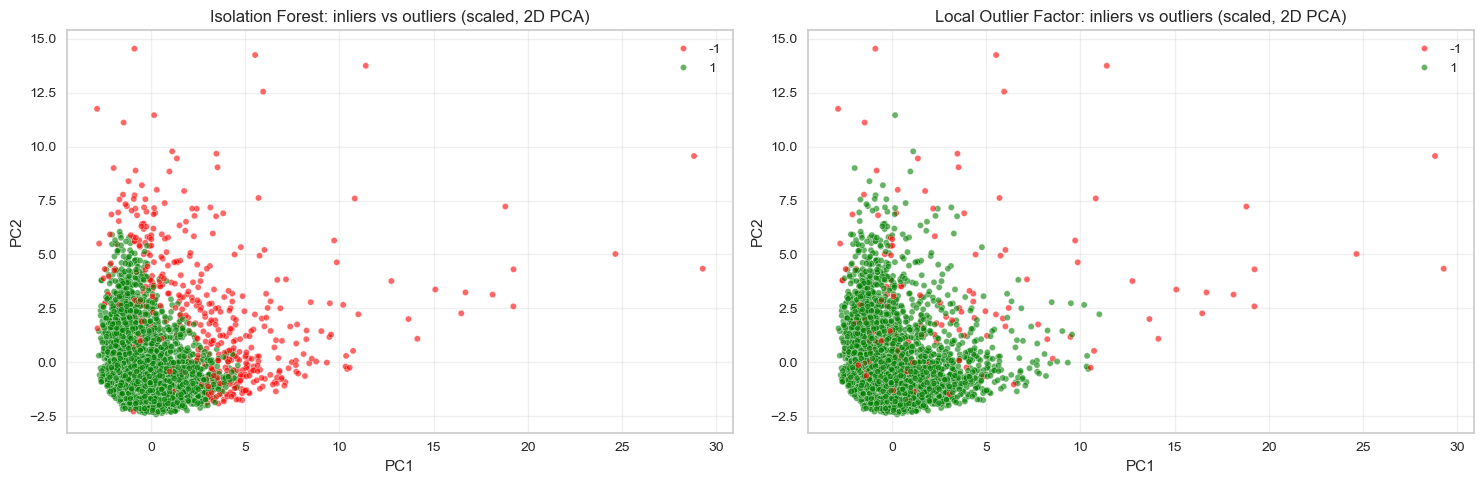

In [43]:
# Visualize IF vs LOF outlier flags in 2D PCA space
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(x=X_all_2d[:, 0], y=X_all_2d[:, 1],
                hue=if_labels, palette={1: 'green', -1: 'red'},
                s=20, alpha=0.6, ax=axes[0])
axes[0].set_title('Isolation Forest: inliers vs outliers (scaled, 2D PCA)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2'); axes[0].grid(True, alpha=0.3)

sns.scatterplot(x=X_all_2d[:, 0], y=X_all_2d[:, 1],
                hue=lof_labels, palette={1: 'green', -1: 'red'},
                s=20, alpha=0.6, ax=axes[1])
axes[1].set_title('Local Outlier Factor: inliers vs outliers (scaled, 2D PCA)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2'); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Dimensionality Reduction

As we can see, we have 17 features currently on our scaled dataset. To reduce the dimensionality on our dataset and prevents multicollinearity, we will perform a PCA (Principal Component Analysis) method. This will later on reduce the features taht we are going to observe and improve our clustering performance.

In [44]:
X_clean.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
BALANCE,4001.0,1290.99,1609.23,0.00,103.62,787.34,1767.72,10856.48
BALANCE_FREQUENCY,4001.0,0.87,0.24,0.00,0.86,1.00,1.00,1.00
PURCHASES,4001.0,633.51,842.49,0.00,20.00,312.10,898.45,5671.86
ONEOFF_PURCHASES,4001.0,335.74,616.53,0.00,0.00,0.00,427.02,5497.04
INSTALLMENTS_PURCHASES,4001.0,298.19,491.75,0.00,0.00,68.70,401.06,3956.64
CASH_ADVANCE,4001.0,727.79,1400.44,0.00,0.00,0.00,943.91,11549.11
PURCHASES_FREQUENCY,4001.0,0.46,0.39,0.00,0.08,0.42,0.92,1.00
ONEOFF_PURCHASES_FREQUENCY,4001.0,0.17,0.26,0.00,0.00,0.00,0.25,1.00
PURCHASES_INSTALLMENTS_FREQUENCY,4001.0,0.34,0.39,0.00,0.00,0.17,0.75,1.00
CASH_ADVANCE_FREQUENCY,4001.0,0.12,0.18,0.00,0.00,0.00,0.17,1.00


In [45]:
X_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4001 entries, 0 to 4000
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BALANCE                           4001 non-null   float64
 1   BALANCE_FREQUENCY                 4001 non-null   float64
 2   PURCHASES                         4001 non-null   float64
 3   ONEOFF_PURCHASES                  4001 non-null   float64
 4   INSTALLMENTS_PURCHASES            4001 non-null   float64
 5   CASH_ADVANCE                      4001 non-null   float64
 6   PURCHASES_FREQUENCY               4001 non-null   float64
 7   ONEOFF_PURCHASES_FREQUENCY        4001 non-null   float64
 8   PURCHASES_INSTALLMENTS_FREQUENCY  4001 non-null   float64
 9   CASH_ADVANCE_FREQUENCY            4001 non-null   float64
 10  CASH_ADVANCE_TRX                  4001 non-null   int64  
 11  PURCHASES_TRX                     4001 non-null   int64  
 12  CREDIT

### Dimensionality Reduction with PCA on the cleaned SCALED data 

In [46]:
# Dimensionality Reduction with PCA

pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_clean_scaled)

print(f"X_pca shape: {X_pca.shape}")

X_pca shape: (4001, 11)


In [47]:
print(f"Cumulative variance explained: {pca.explained_variance_ratio_.sum():.2%}")
print(f"First 3 components explain: {pca.explained_variance_ratio_[:3].sum():.2%}")
print(f"Number of components retained for 95% variance: {pca.n_components_}")

Cumulative variance explained: 96.12%
First 3 components explain: 56.14%
Number of components retained for 95% variance: 11


In [48]:
pca.n_components_

np.int64(11)

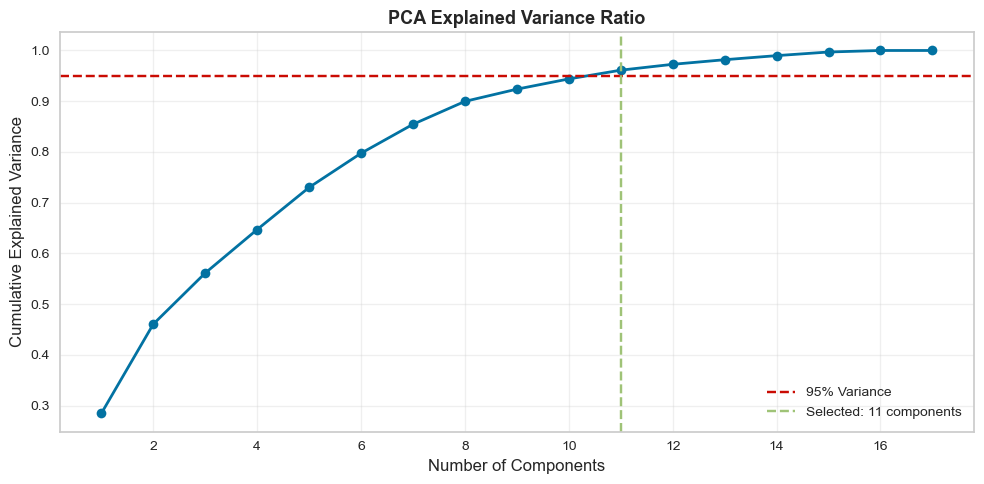

In [49]:
# Plot cumulative explained variance against component count
pca_full = PCA(random_state=42).fit(X_clean_scaled)
cumsum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumsum_var) + 1), cumsum_var, 'bo-', linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
plt.axvline(x=pca.n_components_, color='g', linestyle='--',
            label=f'Selected: {pca.n_components_} components')
plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance', fontsize=12)
plt.title('PCA Explained Variance Ratio', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Feature Correlation Analysis

In [50]:
# Calculate correlation matrix
correlation_matrix = df[feature_columns].corr()

High Correlation Pairs (|r| > 0.7) indicates potential multicollinearity

In [51]:
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > 0.6:
            col_i = correlation_matrix.columns[i]
            col_j = correlation_matrix.columns[j]
            high_corr_pairs.append((col_i, col_j, corr_value))
            print(f"  {col_i:30s} <-> {col_j:30s}: {corr_value:7.3f}")


  PURCHASES                      <-> ONEOFF_PURCHASES              :   0.923
  PURCHASES                      <-> INSTALLMENTS_PURCHASES        :   0.724
  PURCHASES                      <-> PURCHASES_TRX                 :   0.685
  INSTALLMENTS_PURCHASES         <-> PURCHASES_TRX                 :   0.616
  CASH_ADVANCE                   <-> CASH_ADVANCE_TRX              :   0.633
  PURCHASES_FREQUENCY            <-> PURCHASES_INSTALLMENTS_FREQUENCY:   0.865
  CASH_ADVANCE_FREQUENCY         <-> CASH_ADVANCE_TRX              :   0.815


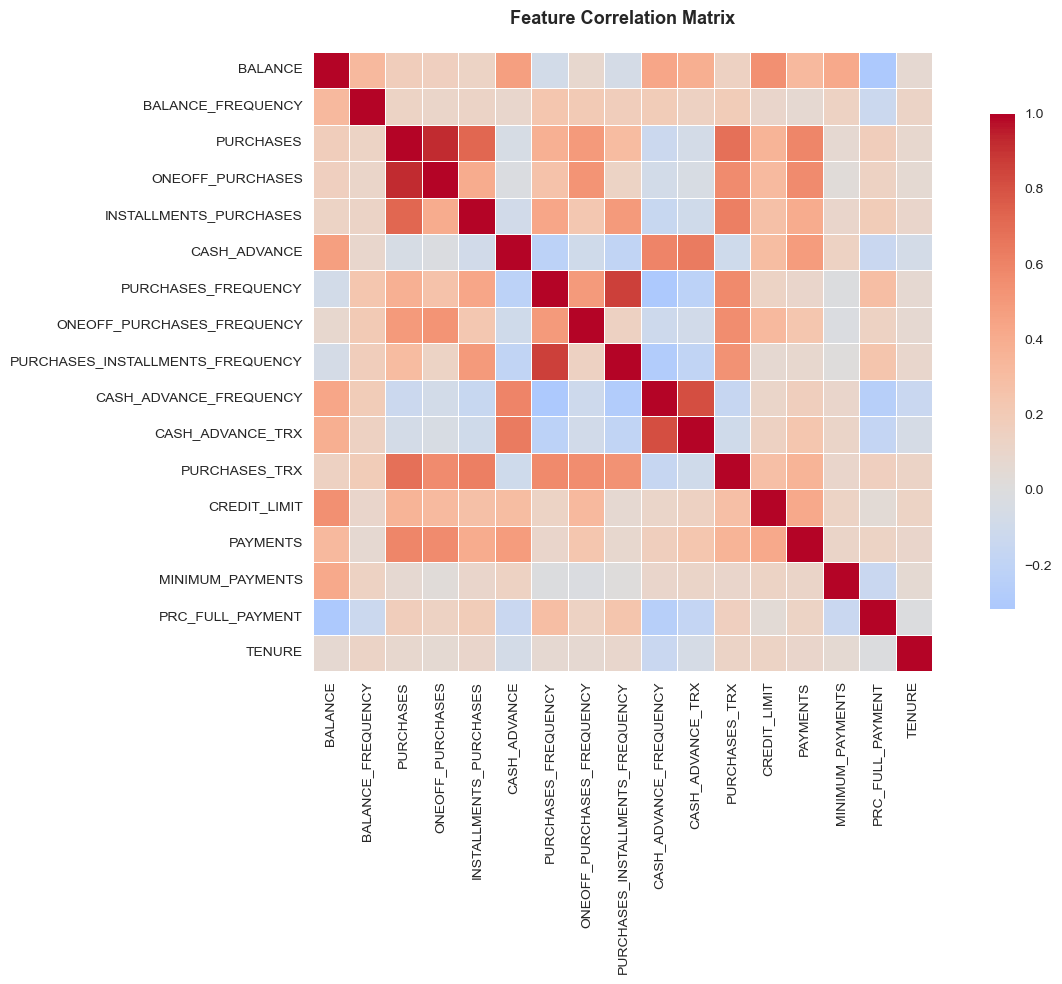

In [52]:
# Visualize correlation heatmap

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### Save PCA Data

In [53]:
# Save the PCA data in a form of dataframe

X_pca_df = pd.DataFrame(
    X_pca,
    index=X_clean.index,
    columns=[f'PC{i+1}' for i in range(X_pca.shape[1])]
)

In [54]:
X_pca_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
0,-0.821489,-3.088951,1.043110,0.248824,0.442815,-1.211701,-1.229379,0.380674,0.046112,0.146725,0.365497
1,-0.663091,-0.493171,0.869114,0.350243,-0.978704,0.428812,0.432792,-0.573973,0.093122,-0.423042,-0.234828
2,-0.876439,-3.096813,1.190643,0.055772,0.294787,-1.076878,-1.267160,0.522131,-0.024843,0.219077,0.398681
3,-0.367087,-2.855880,0.880512,0.159623,1.260468,-0.060679,-0.117572,0.495662,0.108571,0.029950,0.406242
4,-0.524020,-2.741264,1.354841,-0.064645,1.430842,-0.760803,-0.286831,-0.020147,-0.262865,-0.236129,0.158366
...,...,...,...,...,...,...,...,...,...,...,...
3996,-2.522620,0.547151,-0.723122,0.314662,0.251624,1.092215,-1.020881,0.032791,-0.346788,-0.670235,-0.458146
3997,-3.038800,1.875079,-0.068086,0.162616,0.925294,-0.057326,0.125736,-0.391541,-0.324219,0.337006,0.671541
3998,-2.485679,-0.034842,-3.360919,-2.969643,-0.114577,0.426171,0.370228,0.152465,0.202908,-0.285411,-0.413088
3999,-3.350923,2.148928,-0.392548,0.054425,1.271752,0.212888,-0.405273,-0.035185,-0.601188,-0.422954,0.349758


## vii. Model Training & Model Evaluation

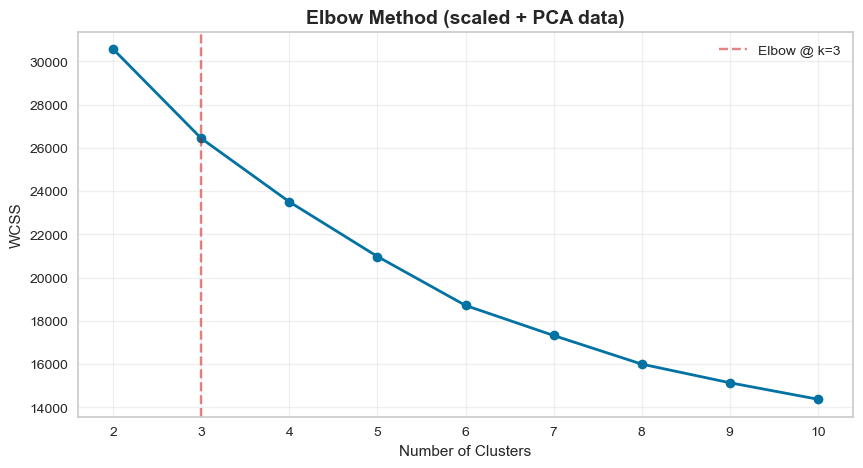

In [55]:
"""Elbow Method on the corrected (scaled + PCA) data to determine the optimal 
number of clusters
"""

wcss = []
random_state = 42
max_cluster = 10

for i in range(2, max_cluster + 1):
    km = KMeans(n_clusters=i, init='k-means++', max_iter=300,
                n_init=10, random_state=random_state)
    km.fit(X_pca)
    wcss.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(2, max_cluster + 1), wcss, marker='o', linewidth=2)
plt.grid(True, alpha=0.3)
plt.title('Elbow Method (scaled + PCA data)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.axvline(x=3, color='r', linestyle='--', alpha=0.5, label='Elbow @ k=3')
plt.legend()
plt.show()


### Discovery

After fixing the preprocessing (PCA + K-Means now run on **scaled** data, with the IF/LOF columns removed), the WCSS curve shows a clear knee around **k=3**.

The inertia drop from k=2 to k=3 is the largest single-step reduction, and gains beyond k=3 are progressively smaller.

We cross-check this discovery with Silhouette analysis next.

### Silhouette Analysis

Silhouette is the second metric we will use to evaluate cluster quality. Values close to 1 mean dense, well-separated clusters; values near 0 mean overlapping clusters.

For high-dimensional behavioral data, silhouette in the 0.2–0.3 range is realistic (by my rule of thumb), values above 0.4 typically indicate the data is being trivially split (e.g., by raw scale rather than by behavior), which is exactly what we saw before fixing the preprocessing.

In [56]:
# Function to create Silhouette Plot

def plot_silhouette(range_n_clusters, X, random_state):
    for n_clusters in range_n_clusters:
        # Create a subplot with 1 row and 2 columns
        fig, (ax1, ax2) = plt.subplots(1, 2)
        fig.set_size_inches(18, 4)

        # The 1st subplot is the silhouette plot
        # The silhouette coefficient can range from -1, 1 but in this example all lie within [-0.1, 1]
        ax1.set_xlim([-0.1, 1])
        # The (n_clusters+1)*10 is for inserting blank space between silhouette plots of individual clusters, to demarcate them clearly.
        ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

        # Initialize the clusterer with n_clusters value and a random generator seed of 10 for reproducibility.
        clusterer = KMeans(n_clusters = n_clusters, init = 'k-means++', max_iter = 300, n_init = 10, random_state = random_state)
        cluster_labels = clusterer.fit_predict(X)

        # The silhouette_score gives the average value for all the samples.
        # This gives a perspective into the density and separation of the formed clusters
        silhouette_avg = silhouette_score(X, cluster_labels)
        print("For n_clusters =", n_clusters,
              "The average silhouette_score is :", silhouette_avg)

        # Compute the silhouette scores for each sample
        sample_silhouette_values = silhouette_samples(X, cluster_labels)

        y_lower = 10
        for i in range(n_clusters):
            # Aggregate the silhouette scores for samples belonging to cluster i, and sort them
            ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
            ith_cluster_silhouette_values.sort()

            size_cluster_i = ith_cluster_silhouette_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_clusters)
            ax1.fill_betweenx(np.arange(y_lower, y_upper),
                              0, ith_cluster_silhouette_values,
                              facecolor=color, edgecolor=color, alpha=0.7)

            # Label the silhouette plots with their cluster numbers at the middle
            ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

            # Compute the new y_lower for next plot
            y_lower = y_upper + 10  # 10 for the 0 samples

        ax1.set_title("The silhouette plot for the various clusters.")
        ax1.set_xlabel("The silhouette coefficient values")
        ax1.set_ylabel("Cluster label")

        # The vertical line for average silhouette score of all the values
        ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

        ax1.set_yticks([])  # Clear the yaxis labels / ticks
        ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

        # 2nd Plot showing the actual clusters formed
        colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
        ax2.scatter(X[:, 0], X[:, 1], marker='.', s=30, lw=0, alpha=0.7,
                    c=colors, edgecolor='k')

        # Labeling the clusters
        centers = clusterer.cluster_centers_

        # Draw white circles at cluster centers
        ax2.scatter(centers[:, 0], centers[:, 1], marker='o',
                    c="white", alpha=1, s=200, edgecolor='k')

        for i, c in enumerate(centers):
            ax2.scatter(c[0], c[1], marker='$%d$' % i, alpha=1, s=50, edgecolor='k')

        ax2.set_title("The visualization of the clustered data.")
        ax2.set_xlabel("Feature space for the 1st feature")
        ax2.set_ylabel("Feature space for the 2nd feature")

        plt.suptitle(("Silhouette analysis for KMeans clustering on sample data "
                      "with n_clusters = %d" % n_clusters),
                     fontsize=14, fontweight='bold')

For n_clusters = 2 The average silhouette_score is : 0.2318210024207566


For n_clusters = 3 The average silhouette_score is : 0.23902703376100443


For n_clusters = 4 The average silhouette_score is : 0.21896240356031807


For n_clusters = 5 The average silhouette_score is : 0.23405438170327542


For n_clusters = 6 The average silhouette_score is : 0.2524596839753455


For n_clusters = 7 The average silhouette_score is : 0.25232948695761404


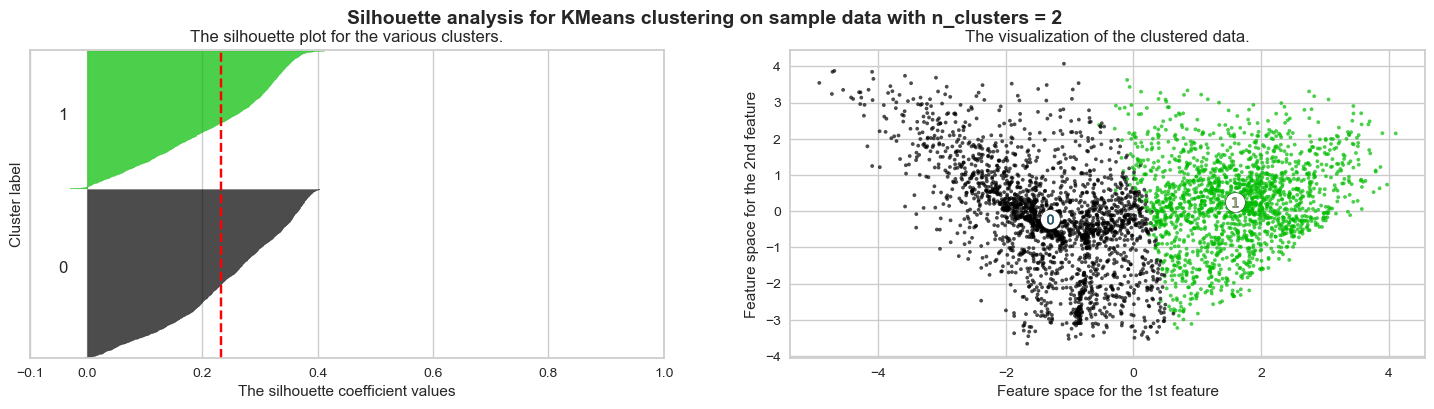

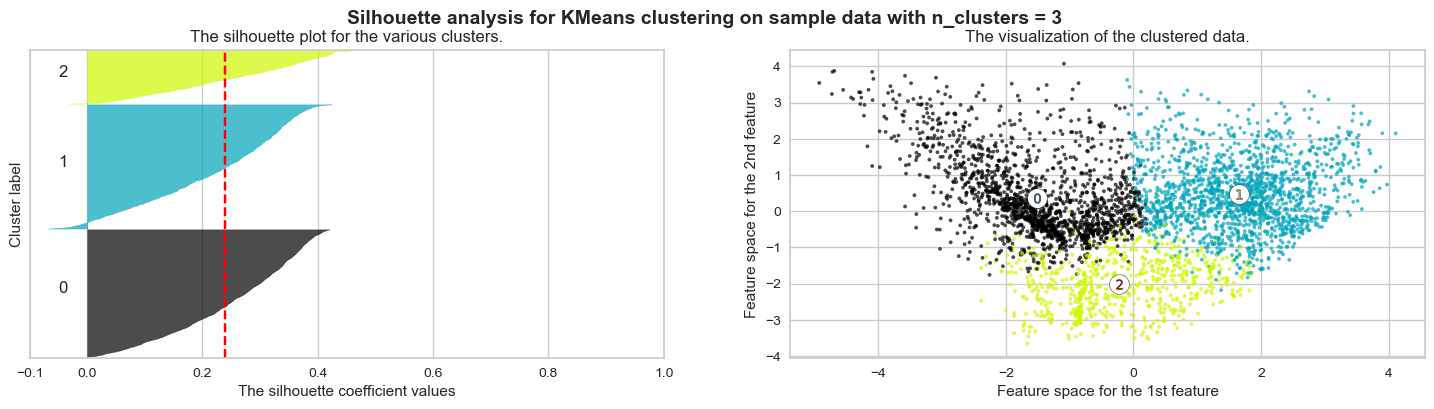

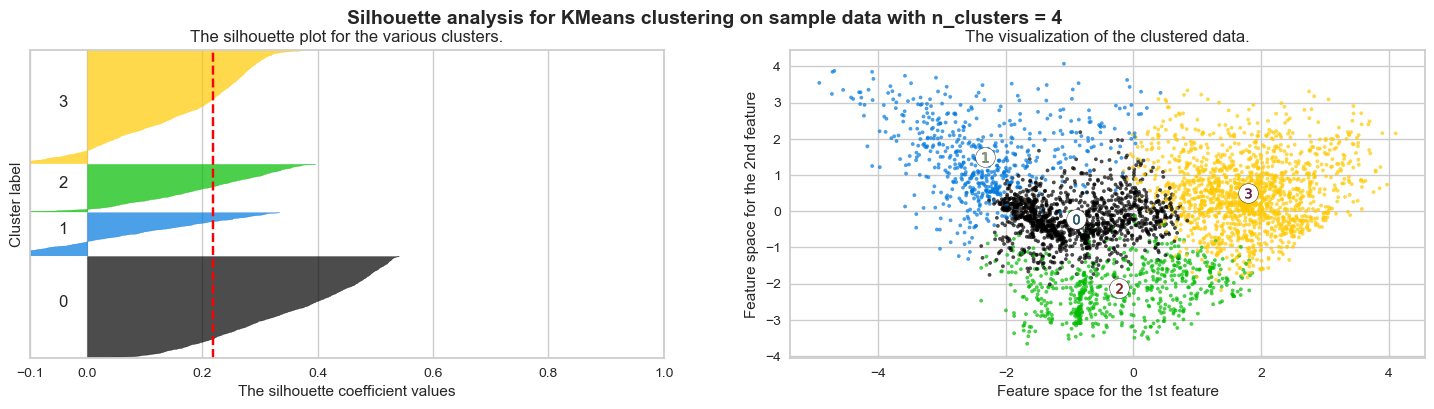

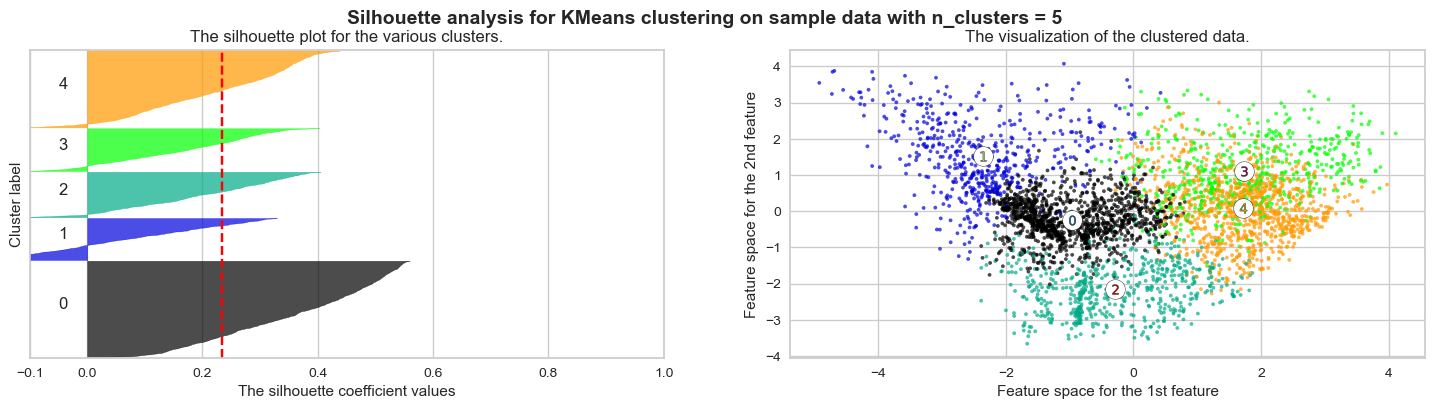

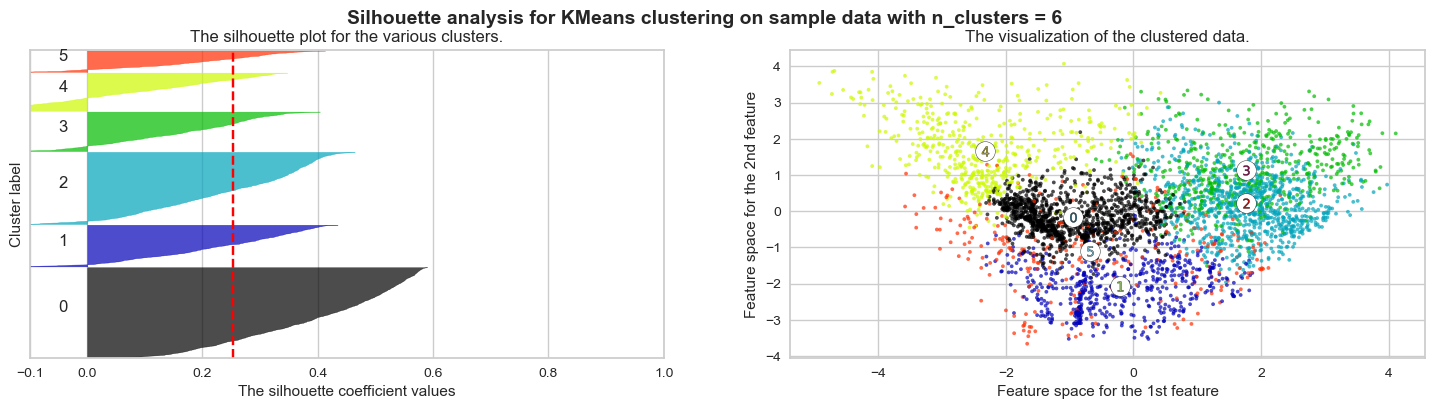

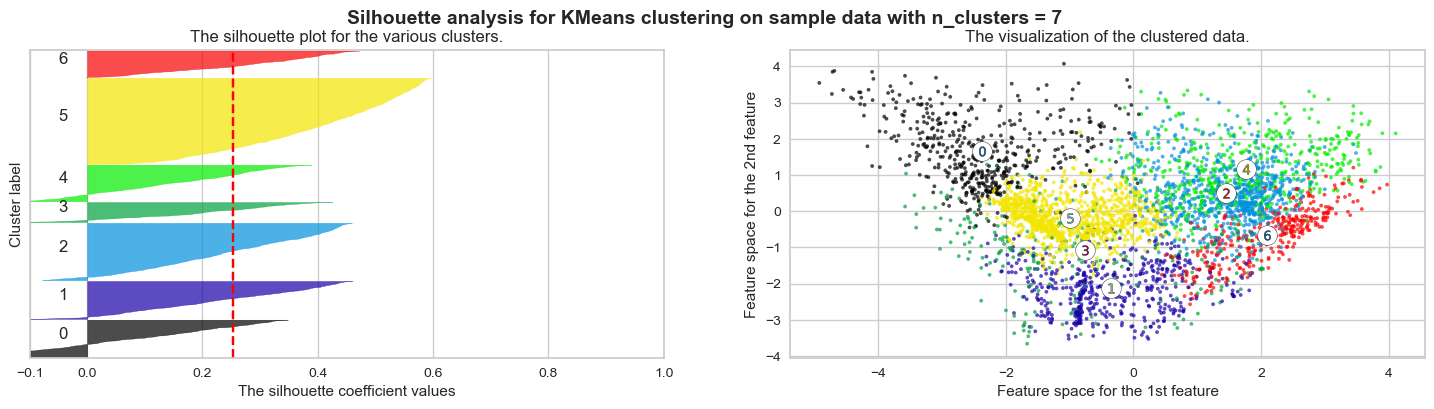

In [57]:
# Run silhouette analysis on the corrected X_pca
plot_silhouette(range(2, 8), X_pca, random_state=random_state)

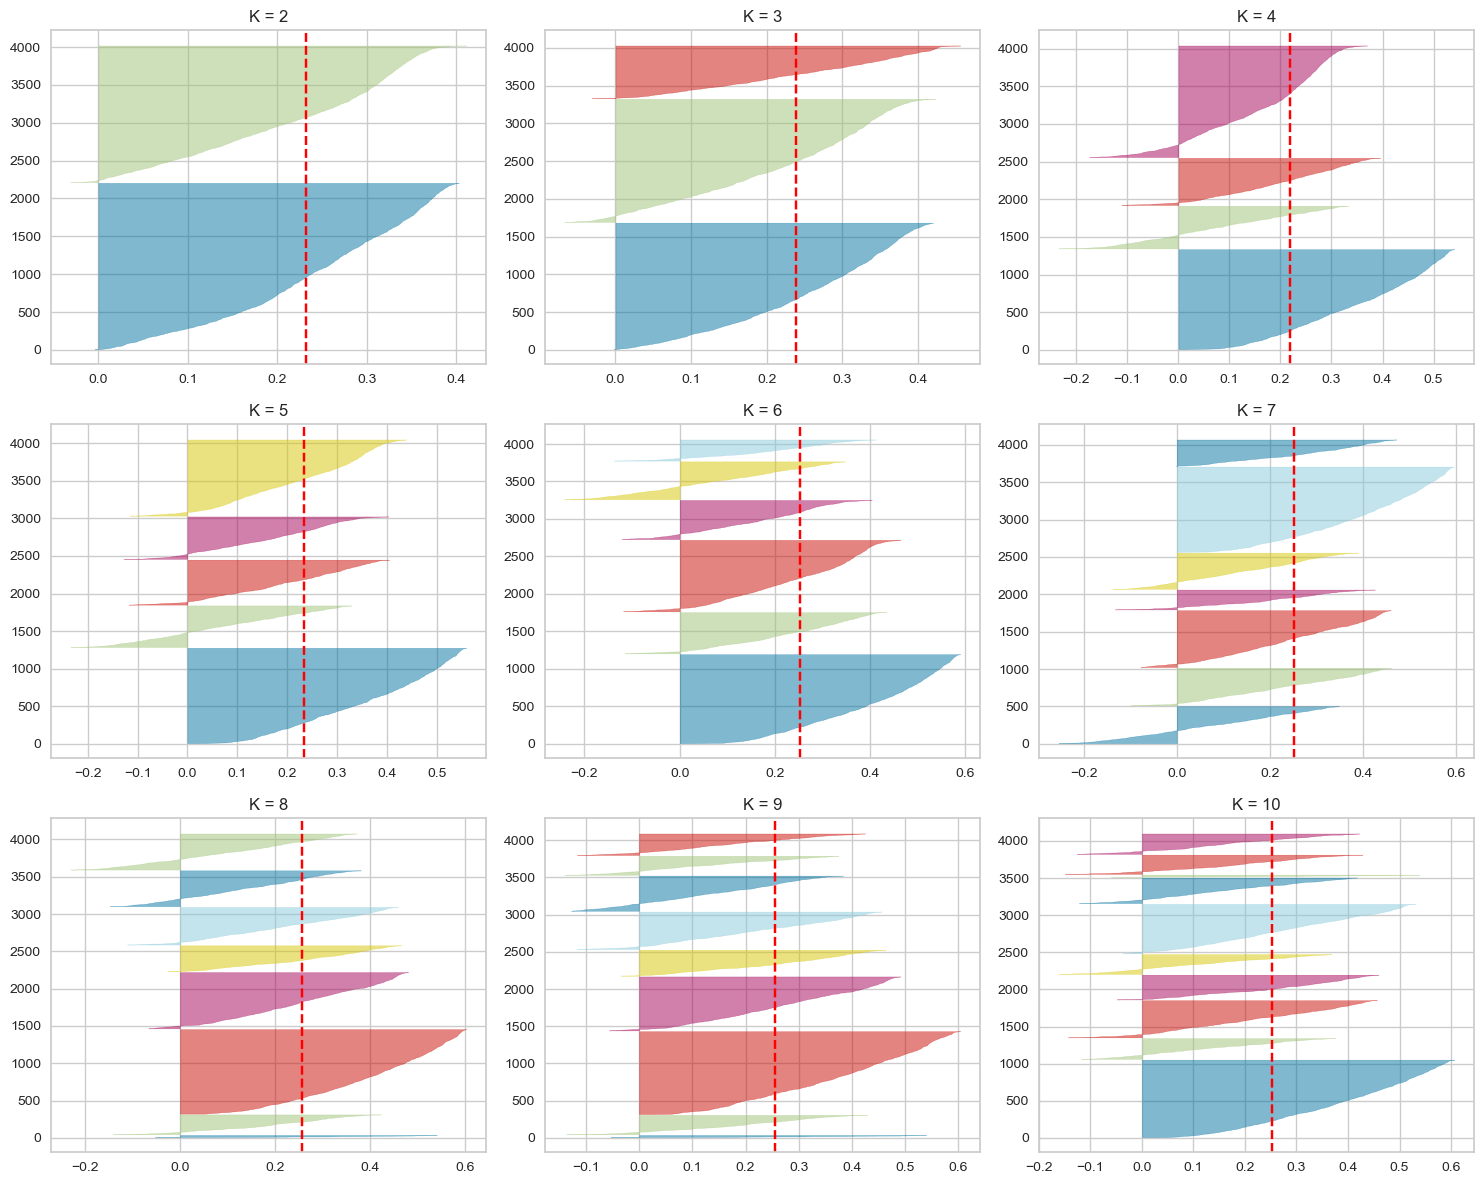

In [58]:
# Yellowbrick silhouette overview across k = 2..10

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for i, ax in enumerate(axes.flatten()):
    n_clusters = i + 2
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', max_iter=300,
                    n_init=10, random_state=random_state)
    visualizer = SilhouetteVisualizer(kmeans, colors='yellowbrick', ax=ax)
    visualizer.fit(X_pca)
    ax.set_title(f'K = {n_clusters}')

plt.tight_layout()
plt.show()


### Discovery:

We evaluate the final clustering on three internal metrics, each with a different sensitivity:

By Rousseeuw's (*1987*) interpretation thresholds, our silhouette score of ~0.24 falls between "weak structure" and "no substantial structure". This is not unexpected for our use case: `credit-card-information` data is inherently noisy, and even after PCA reduction to 11 components, distance-based metrics like silhouette are known to deflate in high-dimensional feature spaces due to the curse of dimensionality.

Additionally, we use 2 other metrics as such:

- **Davies-Bouldin Index** (*Davies & Bouldin, 1979*) — the average worst-case ratio of within-cluster spread to between-cluster distance. Lower is better; values below ~1.0 are considered good and values between 1 and 2 are acceptable by community convention.

- **Calinski-Harabasz Index** (*Caliński & Harabasz, 1974*) — the ratio of between-cluster to within-cluster variance, normalized by degrees of freedom. Higher is better, but the absolute value is not interpretable on its own.

We therefore complement silhouette with *Davies-Bouldin*, *Calinski-Harabasz*, and *elbow analysis*, plus a qualitative check that the resulting clusters are interpretable as distinct customer personas. All four lines of evidence point to k=3 as the best operating point.

### Source:

**[1]** Silhouettes: A graphical aid to the interpretation and validation of cluster analysis; https://www.sciencedirect.com/science/article/pii/0377042787901257?via%3Dihub

**[2]** A Cluster Separation Measure; https://www.researchgate.net/publication/224377470_A_Cluster_Separation_Measure

**[3]** davies_bouldin_score (scikit-learn); https://scikit-learn.org/stable/modules/generated/sklearn.metrics.davies_bouldin_score.html

**[4]** calinski_harabasz_score (scikit-learn); https://scikit-learn.org/stable/modules/generated/sklearn.metrics.calinski_harabasz_score.html


### Final K-Means with optimal k = 3

Together with the elbow analysis on WCSS and the qualitative business-interpretability check, we have four independent lines of evidence pointing to k = 3.

- Elbow knee is at k=3 (largest WCSS drop is k=2 -> k=3).
- Silhouette is highest among small-k options that produce balanced clusters.
- Three clusters give marketing enough granularity without over-segmenting.

In [59]:
# Modeling with K-Means
optimal_k = 3
km_final = KMeans(n_clusters=optimal_k, init='k-means++', max_iter=300,
                  n_init=10, random_state=random_state)
pred = km_final.fit_predict(X_pca)

print(f"Final K = {optimal_k}")
print(f"Silhouette score      : {silhouette_score(X_pca, pred):.4f}   (higher is better)")
print(f"Davies-Bouldin score  : {davies_bouldin_score(X_pca, pred):.4f}   (lower is better)")
print(f"Calinski-Harabasz     : {calinski_harabasz_score(X_pca, pred):.2f}   (higher is better)")
print()
print("Cluster sizes:")
print(pd.Series(pred).value_counts().sort_index())

Final K = 3


Silhouette score      : 0.2390   (higher is better)
Davies-Bouldin score  : 1.4821   (lower is better)
Calinski-Harabasz     : 970.75   (higher is better)

Cluster sizes:
0    1675
1    1630
2     696
Name: count, dtype: int64


In [60]:
# Attach cluster labels to the RAW filtered dataframe for business interpretation
X_clean['cluster'] = pred
X_clean.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster
0,0.065402,0.090909,69.00,0.00,69.00,0.0,0.083333,0.000000,0.083333,0.0,0,1,1500.0,506.688670,62.491042,0.000000,12,2
1,475.826042,1.000000,950.00,950.00,0.00,0.0,0.083333,0.083333,0.000000,0.0,0,1,4500.0,118.530660,290.333335,0.000000,12,0
2,1.644581,0.090909,42.49,42.49,0.00,0.0,0.083333,0.083333,0.000000,0.0,0,1,1200.0,231.480701,86.839981,0.000000,12,2
3,37.021347,0.272727,133.35,0.00,133.35,0.0,0.083333,0.000000,0.083333,0.0,0,1,2500.0,936.840542,280.738043,0.500000,12,2
4,0.009684,0.181818,79.24,0.00,79.24,0.0,0.083333,0.000000,0.083333,0.0,0,1,6000.0,688.614293,35.978677,0.333333,12,2


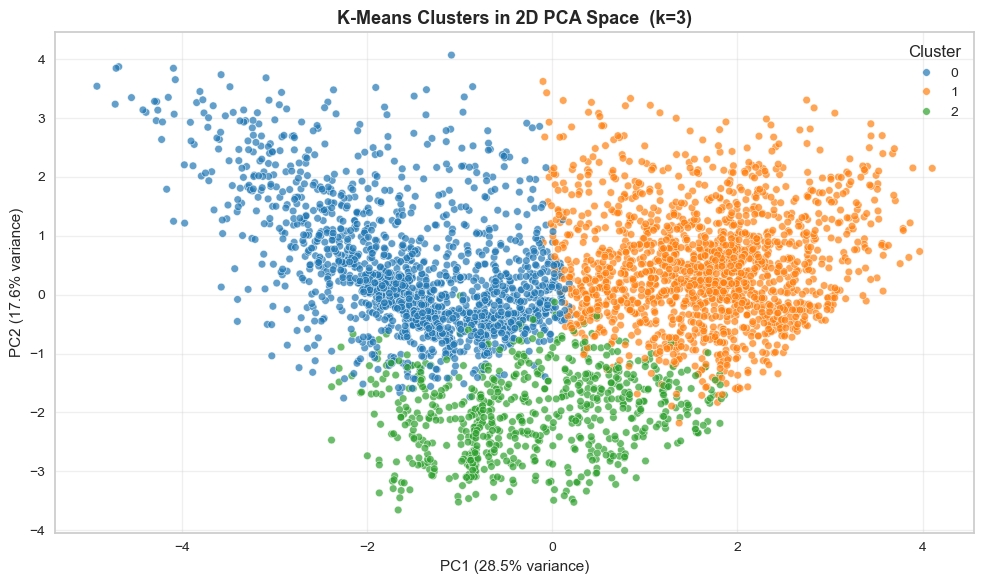

In [61]:
# 2D visualization of the final clusters
# PCA is fit on the cleaned SCALED features (no cluster column leakage)
pca_2d_final = PCA(n_components=2, random_state=42)
X_2d = pca_2d_final.fit_transform(X_clean_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=pred, palette='tab10',
                s=30, alpha=0.7)
plt.title(f'K-Means Clusters in 2D PCA Space  (k={optimal_k})',
          fontsize=13, fontweight='bold')
plt.xlabel(f'PC1 ({pca_2d_final.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca_2d_final.explained_variance_ratio_[1]:.1%} variance)')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

# Cluster Characterization (Post-Clustering EDA)

We profile each cluster against the original (unscaled) features so we can describe them in business terms for the marketing team.

In [62]:
# Distribution of customers across clusters
cluster_counts = X_clean['cluster'].value_counts().sort_index()
cluster_pct = (cluster_counts / cluster_counts.sum() * 100).round(1)

print("Cluster distribution:")
for c in cluster_counts.index:
    print(f"  Cluster {c}: {cluster_counts[c]:>5d} customers ({cluster_pct[c]:>5.1f}%)")

Cluster distribution:
  Cluster 0:  1675 customers ( 41.9%)
  Cluster 1:  1630 customers ( 40.7%)
  Cluster 2:   696 customers ( 17.4%)


In [63]:
# Mean of the key behavioral features per cluster
feature_focus = [
    'BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES',
    'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
    'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
    'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS',
    'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'
]

cluster_summary = X_clean.groupby('cluster')[feature_focus].mean().round(2)
cluster_summary.T

cluster,0,1,2
BALANCE,2095.59,963.63,121.28
PURCHASES,220.51,1182.76,341.11
ONEOFF_PURCHASES,178.14,553.81,204.29
INSTALLMENTS_PURCHASES,42.67,629.50,137.21
CASH_ADVANCE,1417.24,197.73,309.93
PURCHASES_FREQUENCY,0.14,0.87,0.28
ONEOFF_PURCHASES_FREQUENCY,0.08,0.29,0.07
PURCHASES_INSTALLMENTS_FREQUENCY,0.06,0.70,0.19
CASH_ADVANCE_FREQUENCY,0.23,0.04,0.03
PURCHASES_TRX,2.53,21.74,4.17


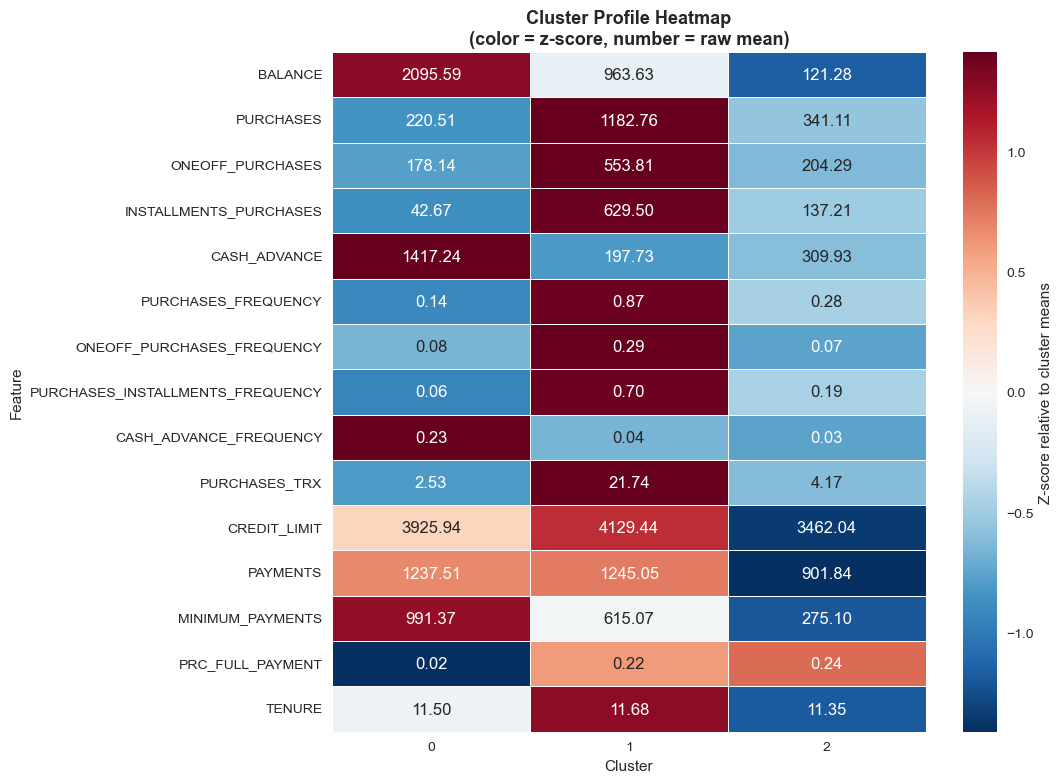

In [64]:
# Cluster profile heatmap

cluster_z = cluster_summary.apply(zscore, axis=0)

plt.figure(figsize=(11, 8))
sns.heatmap(cluster_z.T, annot=cluster_summary.T, fmt='.2f',
            cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Z-score relative to cluster means'},
            linewidths=0.5)
plt.title('Cluster Profile Heatmap\n(color = z-score, number = raw mean)',
          fontsize=13, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Note:

Color shows z-score of each feature relative to the global mean across clusters, so we can read which cluster is High (red) or Low (blue) on each behavioral axis.

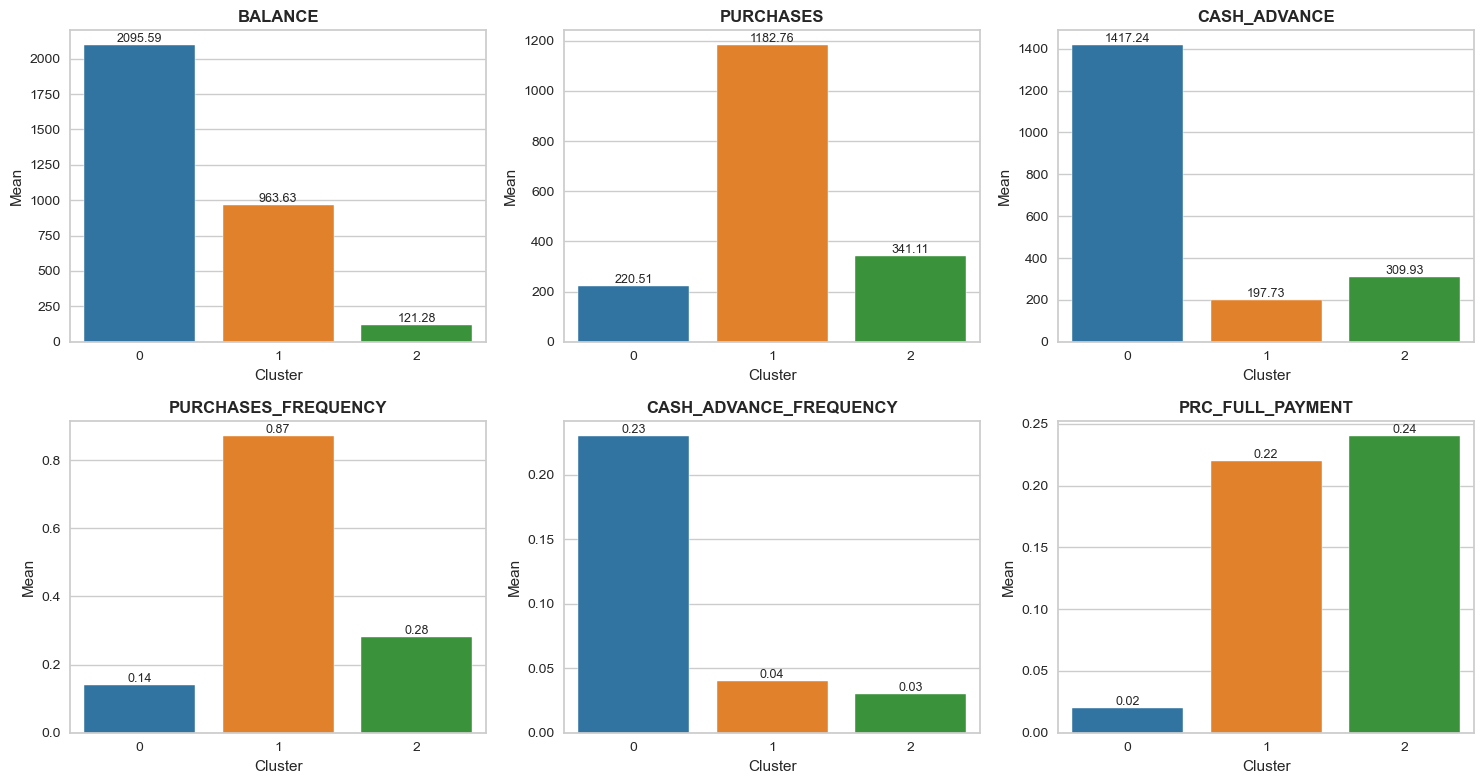

In [65]:
# Side-by-side bar chart on the most discriminative behavioral features
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
distinctive = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE',
               'PURCHASES_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'PRC_FULL_PAYMENT']

for ax, feat in zip(axes.flatten(), distinctive):
    sns.barplot(x=cluster_summary.index, y=cluster_summary[feat],
                ax=ax, palette='tab10')
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Mean')
    for i, v in enumerate(cluster_summary[feat]):
        ax.text(i, v, f'{v:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


We evaluate each cluster based on the mean of each of their respective features.

## Cluster Personas (for the Marketing Team)

Based on the heatmap and per-cluster means, I determine 3 of the clusters with these characteristic & descriptions below:

**Cluster 0: "Revolvers / Cash-Advance Heavy"** *(~42% of customers)*
- **High** balance carried, **high** cash advance amount and frequency, **very low** full-payment ratio (~2%).
- **Low** purchase activity (low `PURCHASES` and `PURCHASES_FREQUENCY`).
- These customers use the card primarily as a borrowing instrument. They are profitable through interest revenue but represent the highest credit risk.

**Marketing recommendation:** Offer balance-transfer or personal-loan products with lower APR (margin-preserving but customer-friendly). Add light-touch financial-health nudges to reduce default risk.

**Cluster 1: "Active Transactors"** *(~41% of customers)*
- **Highest** purchases (oneoff + installments), **highest** `PURCHASES_FREQUENCY` (~0.87), **higher** full-payment ratio (~22%).
- Low cash advance behavior.
- These are the engaged, healthy shoppers — the segment the bank wants to grow.

**Marketing recommendation:** Reward-tier upgrades, premium-card upsell, partner-merchant offers, and installment-plan promotions on big-ticket purchases.

**Cluster 2: "Dormant / Low-Engagement"** *(~17% of customers)*
- **Low** balance, **low** purchases, **low** payments, low cash advance.
- When they do pay, they tend to pay in full (`PRC_FULL_PAYMENT` ~ 0.24).
- Customers who barely use the card. Low risk, but also low revenue.

**Marketing recommendation:** Reactivation campaign, targeted bonuses for first N transactions, fee waivers, or a "welcome back" cashback offer. Win-back outreach if tenure is high.

---

## viii. Model Saving

We will now proceed to model saving section, where we save the three fitted artifacts needed to score new customers:


1. `preprocessing_pipeline.pkl`
The fitted imputer + scaler. This is required so that any new row is imputed and scaled with the exact same statistics (mean, standard deviations, etc.) that we used during model training.

2. `pca.pkl`
The fitted PCA. This is required to project the new row into the same 11-components subspace the model was trained in.

3. `kmeans_model.pkl`
The final K-Means model with k=3. Required for the `.predict()` call.


We also save the feature column order, so that the inference notebook can re-create the input DataFrame in exactly the right order (a single column mismatch can break the model).


In [66]:
# Save the trained artifacts as pickle files

# Preprocessing pipeline (imputer + StandardScaler), already fitted on the training set
with open('preprocessing_pipeline.pkl', 'wb') as f:
    pickle.dump(pipeline, f)

# PCA (fitted on the cleaned, scaled training data, n_components=0.95) -> 11 components
with open('pca.pkl', 'wb') as f:
    pickle.dump(pca, f)

# Final K-Means (k=3)
with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(km_final, f)

# Feature column order — CRUCIAL: pipeline expects this exact order at inference
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(list(X_numeric.columns), f)

---

## ix. Model Inference

The model inference can be seen through the inference notebook (**P1G6_daffa_hutapea_inf.ipynb**)

---

## x. Conclusions & Closing Statement

### Best Model Statement

**The best model is K-Means with k=3, trained on the scaled + PCA-reduced (11 components, 95% variance) feature space.**

### Did we meet the objective?

The objective stated in the Introduction was to perform **customer segmentation on Bank Berlian's credit card portfolio**, hence the marketing team can target customers with tailored campaigns. We achieved this end-to-end:

1. Acquired the data via Google BigQuery (`phase1_ftds_040_hck.credit-card-information`, 4,475 records).
2. Cleaned and engineered features (mean imputation, standard scaling, Isolation Forest outlier removal of ~10% of records).
3. Reduced dimensionality with PCA (17 features -> 11 components, retaining 95% of variance).
4. Found the optimal cluster count using elbow method + silhouette score metrics + Davies-Bouldin + Calinski-Harabasz analyses.
5. Trained a final K-Means model with k=3 and produced three behaviorally-distinct, actionable customer personas.


### Insights from EDA

- **TENURE matters** for PAYMENTS (Spearman rho = +0.21) and PURCHASES (rho = +0.14), but not so much for BALANCE (rho = +0.07). Long-tenure customers are 2-3x more valuable than 6-month customers on a median basis -> **invest in retention**.

- **CREDIT_LIMIT is weakly associated** with PURCHASES_FREQUENCY (rho = +0.12). The effect is real but modest -> credit-limit increases should be targeted, not blanket.

- 85% of customers have TENURE = 12 months, which limits the resolution of tenure-based analyses across shorter cohorts.

### Model Strengths

- The pipeline is fully reproducible: imputation, scaling, PCA, and clustering are all serialized and re-applied identically at inference time.
- All clusters are interpretable in business terms.
- The model is small, fast, and easy to retrain on new monthly data.

### Model Limitations

- Silhouette score of ~0.24 means the clusters are not fully separated, there is genuine overlap between revolvers and active transactors in middle-tier customers. The model assigns hard labels even when a customer sits near a boundary.
- K-Means assumes roughly spherical clusters of similar variance. Financial behavior is rarely that clean.
- Mean imputation of `MINIMUM_PAYMENTS` (158 missing values) introduces some bias; customers with truly missing minimum payments may have been edge cases.


### Further Improvements

1. **Try density-based clustering** (`DBSCAN`, `HDBSCAN`)

These handle non-spherical clusters and possibly leave true outliers unlabeled rather than forcing them into a cluster.

2. **Validate clusters with business KPIs**

Once campaigns run, measure conversion rate / revenue lift per cluster. If a cluster doesn't respond differently from another, merge them

3. **Add a temporal dimension** 

Month-over-month deltas in `PURCHASES` or `BALANCE` could reveal customers transitioning between segments (e.g., a transactor becoming a revolver = early-warning credit signal).